# Appendix B

## MSDS458 Research Assignment 3:
Soraya Karimi Butler <br>
02/22/2026


Experiments A: EDA: For NLP projects, it is very important to do extensive EDA and do the preprocessing before defining models. These are the suggestions.

(a) Vocabulary Size: Tweak the vocabulary size, at least 3 levels.

(b) Editing the Vocabulary: Try unedited most frequent words, VS edit the list by deleting the most frequent words such as articles, ‘the’, ‘a’, etc.

(c) Output sequence length: Use the default VS set it to a fixed number

Experiments B: RNN: Try several experiments by tweaking (i) architecture (ii) Bidirectional/unidirectional & other hyper parameters, including regularization.

Experiments C: LSTM: Try several experiments by tweaking (i) architecture (ii) Bidirectional/unidirectional & other hyper parameters, including regularization.

Experiment D: 1D CNN

Bottomline: You need to  do at least 10 experiments or more.

Result:  Create a table with the accuracy and loss for train/test/validation & process time for all the models


# Imports

In [1]:
import datetime
from packaging import version
from collections import Counter
import numpy as np
import pandas as pd
import time
import os
import re
import string

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as k
from tensorflow.keras import layers, models, regularizers

In [2]:
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

In [3]:
# verify tensorflow version
print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >=2

This notebook requires TensorFlow 2.0 or above
TensorFlow version:  2.19.0


In [4]:
# mount colab drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
tf.test.gpu_device_name()

'/device:GPU:0'

# Visualization Utility Functions

In [6]:
def print_validation_report(test_labels, predictions):
    print("Classification Report")
    print(classification_report(test_labels, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(test_labels, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(test_labels, predictions))))

def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8,8))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

In [7]:
def get_sequence_lengths(vectorizer, dataset, sample_size):
    texts = [text.numpy().decode("utf-8") for text, _ in dataset.take(sample_size)]
    sequences = vectorizer(texts)
    lengths = tf.reduce_sum(tf.cast(sequences != 0, tf.int32), axis=1)
    return lengths.numpy()

def compute_oov_rate(vectorizer, dataset, sample_size):
    texts = [text.numpy().decode("utf-8") for text, _ in dataset.take(sample_size)]
    sequences = vectorizer(texts)

    oov_index = 1  # 0=padding, 1=[UNK]
    total_tokens = tf.reduce_sum(tf.cast(sequences != 0, tf.float32))
    oov_tokens = tf.reduce_sum(tf.cast(sequences == oov_index, tf.float32))

    return (oov_tokens / total_tokens).numpy()

def plot_top_words(vectorizer, vocab_size, top_n_words):
    vocab = vectorizer.get_vocabulary()[:top_n_words]

    plt.figure()
    plt.barh(vocab[::-1], range(top_n_words, 0, -1))
    plt.title(f"Top {top_n_words} Words (Vocab={vocab_size})")
    plt.xlabel("Frequency Rank")
    plt.show()


def plot_length_distribution(lengths, vocab_size):
    plt.figure()
    plt.hist(lengths, bins=50)
    plt.title(f"Sequence Length Distribution (Vocab={vocab_size})")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Frequency")
    plt.show()



In [8]:
def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

def print_validation_report(test_labels, predictions):
    print("Classification Report")
    print(classification_report(test_labels, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(test_labels, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(test_labels, predictions))))

def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16,12))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

# Load & Explore AG News Subset

In [9]:
(ds_train, ds_test), ds_info = tfds.load(
    "ag_news_subset",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)


AUTOTUNE = tf.data.AUTOTUNE
train_text = ds_train.map(lambda text, label: text).batch(1024).prefetch(AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.RXJRQ7_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.RXJRQ7_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.


In [10]:
tfds.as_dataframe(ds_train.take(10),ds_info)

,description,label
0,"AMD #39;s new dual-core Opteron chip is designed mainly for corporate computing applications, including databases, Web services, and financial transactions.",3 (Sci/Tech)
1,Reuters - Major League Baseball\Monday announced a decision on the appeal filed by Chicago Cubs\pitcher Kerry Wood regarding a suspension stemming from an\incident earlier this season.,1 (Sports)
2,"President Bush #39;s quot;revenue-neutral quot; tax reform needs losers to balance its winners, and people claiming the federal deduction for state and local taxes may be in administration planners #39; sights, news reports say.",2 (Business)
3,"Britain will run out of leading scientists unless science education is improved, says Professor Colin Pillinger.",3 (Sci/Tech)
4,"London, England (Sports Network) - England midfielder Steven Gerrard injured his groin late in Thursday #39;s training session, but is hopeful he will be ready for Saturday #39;s World Cup qualifier against Austria.",1 (Sports)
5,TOKYO - Sony Corp. is banking on the \$3 billion deal to acquire Hollywood studio Metro-Goldwyn-Mayer Inc...,0 (World)
6,"Giant pandas may well prefer bamboo to laptops, but wireless technology is helping researchers in China in their efforts to protect the engandered animals living in the remote Wolong Nature Reserve.",3 (Sci/Tech)
7,"VILNIUS, Lithuania - Lithuania #39;s main parties formed an alliance to try to keep a Russian-born tycoon and his populist promises out of the government in Sunday #39;s second round of parliamentary elections in this Baltic country.",0 (World)
8,Witnesses in the trial of a US soldier charged with abusing prisoners at Abu Ghraib have told the court that the CIA sometimes directed abuse and orders were received from military command to toughen interrogations.,0 (World)
9,"Dan Olsen of Ponte Vedra Beach, Fla., shot a 7-under 65 Thursday to take a one-shot lead after two rounds of the PGA Tour qualifying tournament.",1 (Sports)


In [11]:
# review labels
categories =dict(enumerate(ds_info.features["label"].names))
print(f'Dictionary: ',categories)

Dictionary:  {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


In [13]:
train_text

<_PrefetchDataset element_spec=TensorSpec(shape=(None,), dtype=tf.string, name=None)>

In [12]:
# review class balance
train_categories = [categories[label] for label in ds_train.map(lambda text, label: label).as_numpy_iterator()]
Counter(train_categories).most_common()

KeyboardInterrupt: 

# EDA: Statistics without edited vocabulary

In [ ]:
# vectorize the data
%%time
max_tokens = None
text_vectorization=layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
)
text_vectorization.adapt(train_text)

CPU times: user 5.01 s, sys: 1.53 s, total: 6.55 s
Wall time: 2.22 s


In [ ]:
%%time
doc_sizes = []
corpus = []
for example, _ in ds_train.as_numpy_iterator():
  enc_example = text_vectorization(example)
  doc_sizes.append(len(enc_example))
  corpus+=list(enc_example.numpy())

CPU times: user 15min 24s, sys: 45.1 s, total: 16min 9s
Wall time: 14min 39s


In [ ]:
print(f"There are {len(corpus)} words in the corpus of {len(doc_sizes)} news articles.")
print(f"Each news article has between {min(doc_sizes)} and {max(doc_sizes)} tokens in it.")

There are 3677503 words in the corpus of 120000 news articles.
Each news article has between 3 and 173 tokens in it.


In [ ]:
print(f"There are {len(text_vectorization.get_vocabulary())} vocabulary words in the corpus.")

There are 93145 vocabulary words in the corpus.


In [ ]:
vocab = np.array(text_vectorization.get_vocabulary())
print(vocab[:50])

['' '[UNK]' 'the' 'a' 'to' 'of' 'in' 'and' 'on' 'for' 'that' '39s' 'with'
 'as' 'its' 'at' 'is' 'said' 'by' 'it' 'has' 'new' 'an' 'from' 'his' 'us'
 'will' 'was' 'reuters' 'after' 'have' 'be' 'their' 'are' 'over' 'ap' 'he'
 'but' 'two' 'first' 'this' 'more' 'monday' 'wednesday' 'tuesday'
 'thursday' 'company' 'up' 'friday' 'inc']


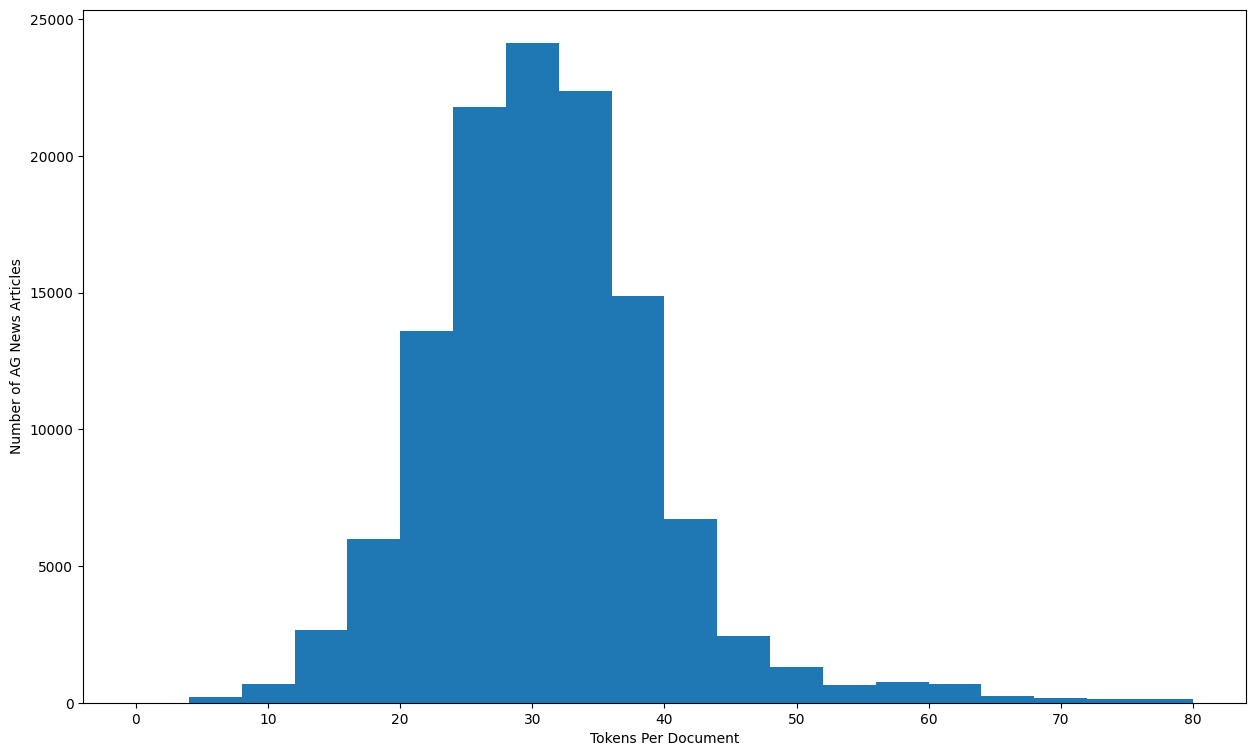

In [ ]:
plt.figure(figsize=(15,9))
plt.hist(doc_sizes, bins=20,range = (0,80))
plt.xlabel("Tokens Per Document")
plt.ylabel("Number of AG News Articles");

In [ ]:
def build_model(vectorizer, num_classes):
    model = models.Sequential([
        vectorizer,
        layers.Embedding(input_dim=vectorizer.vocabulary_size(), output_dim=64, mask_zero=True),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Determine accuracy with this vocab
import time

start = time.time()
print("\n--- Training without stopwords removed ---")
model_no_stop = build_model(text_vectorization, 4)
model_no_stop.fit(ds_train.batch(32),  epochs=3)
stop = time.time()
print("Total time elapsed (s)", stop-start)


--- Training without stopwords removed ---
Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.8294 - loss: 0.4890
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9349 - loss: 0.1898
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9548 - loss: 0.1317
Total time elapsed (s) 62.20441651344299


In [ ]:
test_loss, test_acc = model_no_stop.evaluate(ds_test.batch(32))
print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9067 - loss: 0.3239
Test accuracy: 0.9038158059120178


# EDA: Statistics with edited vocabulary

In [ ]:
def custom_stopwords(input_text):
    lowercase = tf.strings.lower(input_text)
    stripped_punct = tf.strings.regex_replace(lowercase
                                  ,'[%s]' % re.escape(string.punctuation)
                                  ,'')
    return tf.strings.regex_replace(stripped_punct, r'\b(' + r'|'.join(STOPWORDS) + r')\b\s*',"")

In [ ]:
nltk.download('stopwords',quiet=True)
STOPWORDS = stopwords.words("english")

In [ ]:
STOPWORDS

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
# vectorize the data
%%time
max_tokens = None
text_vectorization=layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    standardize=custom_stopwords
)
text_vectorization.adapt(train_text)

CPU times: user 5.21 s, sys: 1.51 s, total: 6.72 s
Wall time: 2.37 s


In [ ]:
%%time
doc_sizes = []
corpus = []
for example, _ in ds_train.as_numpy_iterator():
  enc_example = text_vectorization(example)
  doc_sizes.append(len(enc_example))
  corpus+=list(enc_example.numpy())

CPU times: user 15min 39s, sys: 43.6 s, total: 16min 22s
Wall time: 14min 52s


In [ ]:
"""
There are 2579419 words in the corpus of 127600 news articles.
Each news article has between 2 and 95 tokens in it.
"""
print(f"There are {len(corpus)} words in the corpus of {len(doc_sizes)} news articles.")
print(f"Each news article has between {min(doc_sizes)} and {max(doc_sizes)} tokens in it.")

There are 2426381 words in the corpus of 120000 news articles.
Each news article has between 2 and 95 tokens in it.


In [ ]:
"""
There are 95827 vocabulary words in the corpus.
"""
print(f"There are {len(text_vectorization.get_vocabulary())} vocabulary words in the corpus.")

There are 92996 vocabulary words in the corpus.


In [ ]:
vocab = np.array(text_vectorization.get_vocabulary())
print(vocab[:50])

['' '[UNK]' '39s' 'said' 'new' 'us' 'reuters' 'ap' 'two' 'first' 'monday'
 'wednesday' 'tuesday' 'thursday' 'company' 'friday' 'inc' 'one' 'world'
 'yesterday' 'last' 'york' 'year' 'president' 'million' 'oil' 'corp'
 'united' 'would' 'sunday' 'week' 'years' 'today' 'people' 'three'
 'government' 'could' 'quot' 'group' 'time' 'percent' 'game' 'saturday'
 'software' 'night' 'prices' 'iraq' 'next' 'security' 'announced']


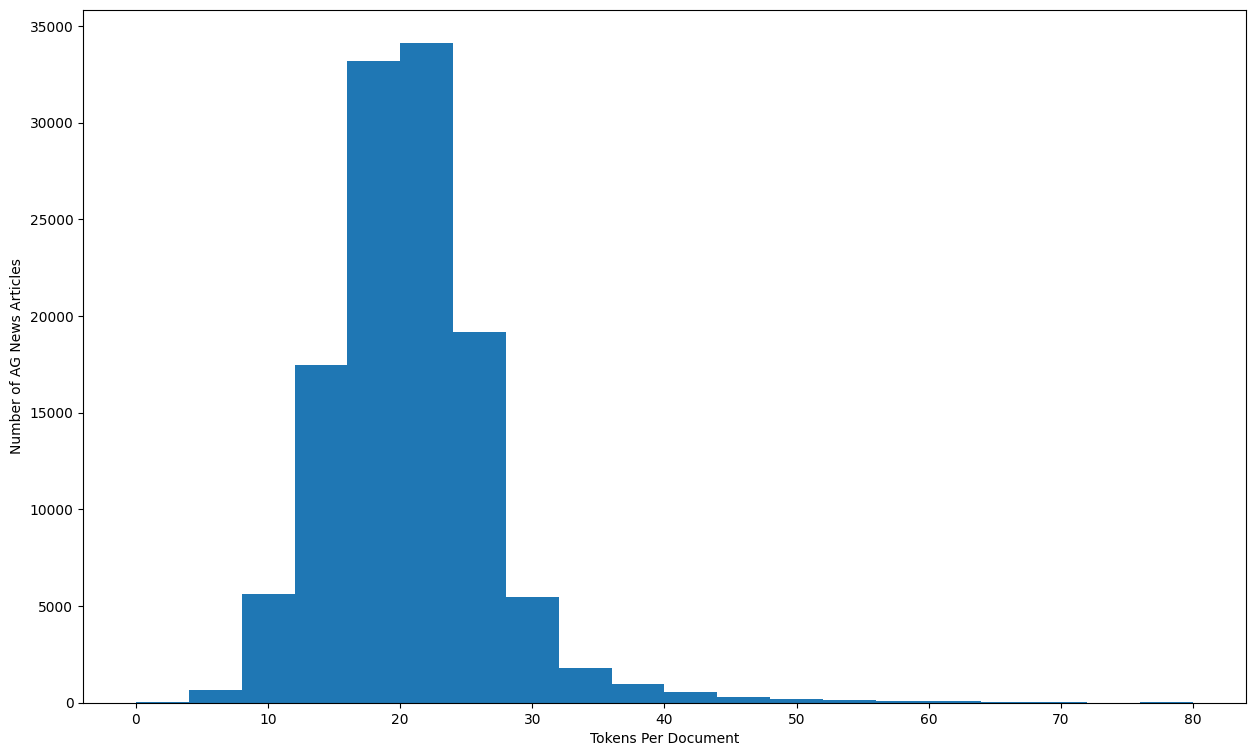

In [ ]:
plt.figure(figsize=(15,9))
plt.hist(doc_sizes, bins=20,range = (0,80))
plt.xlabel("Tokens Per Document")
plt.ylabel("Number of AG News Articles");

In [ ]:
def build_model(vectorizer, num_classes):
    model = models.Sequential([
        vectorizer,
        layers.Embedding(input_dim=vectorizer.vocabulary_size(), output_dim=64, mask_zero=True),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Determine accuracy with this vocab

start = time.time()
print("\n--- Training with stopwords removed ---")
model_with_stop = build_model(text_vectorization, 4)
model_with_stop.fit(ds_train.batch(32),  epochs=3)
stop = time.time()
print("Total time elapsed (s)", stop-start)


--- Training with stopwords removed ---
Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8516 - loss: 0.4733
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9372 - loss: 0.1827
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9572 - loss: 0.1216
Total time elapsed (s) 62.00930714607239


In [ ]:
test_loss, test_acc = model_with_stop.evaluate(ds_test.batch(32))
print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9053 - loss: 0.3483
Test accuracy: 0.9011842012405396


# EDA: Statistics with edited vocabulary, with fixed sequence length

In [ ]:
# vectorize the data
%%time
fixed_len = 96  # try 50, 100, 200 for further experiments

max_tokens = None
text_vectorization=layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    standardize=custom_stopwords,
     output_sequence_length=fixed_len,
)
text_vectorization.adapt(train_text)

CPU times: user 5.22 s, sys: 1.61 s, total: 6.82 s
Wall time: 2.4 s


In [ ]:
%%time
doc_sizes = []
corpus = []
for example, _ in ds_train.as_numpy_iterator():
  enc_example = text_vectorization(example)
  doc_sizes.append(len(enc_example))
  corpus+=list(enc_example.numpy())

CPU times: user 18min 40s, sys: 44 s, total: 19min 24s
Wall time: 17min 53s


In [ ]:
print(f"There are {len(corpus)} words in the corpus of {len(doc_sizes)} news articles.")
print(f"Each news article has between {min(doc_sizes)} and {max(doc_sizes)} tokens in it.")

There are 11520000 words in the corpus of 120000 news articles.
Each news article has between 96 and 96 tokens in it.


In [ ]:
print(f"There are {len(text_vectorization.get_vocabulary())} vocabulary words in the corpus.")

There are 92996 vocabulary words in the corpus.


In [ ]:
vocab = np.array(text_vectorization.get_vocabulary())
print(vocab[:50])

['' '[UNK]' '39s' 'said' 'new' 'us' 'reuters' 'ap' 'two' 'first' 'monday'
 'wednesday' 'tuesday' 'thursday' 'company' 'friday' 'inc' 'one' 'world'
 'yesterday' 'last' 'york' 'year' 'president' 'million' 'oil' 'corp'
 'united' 'would' 'sunday' 'week' 'years' 'today' 'people' 'three'
 'government' 'could' 'quot' 'group' 'time' 'percent' 'game' 'saturday'
 'software' 'night' 'prices' 'iraq' 'next' 'security' 'announced']


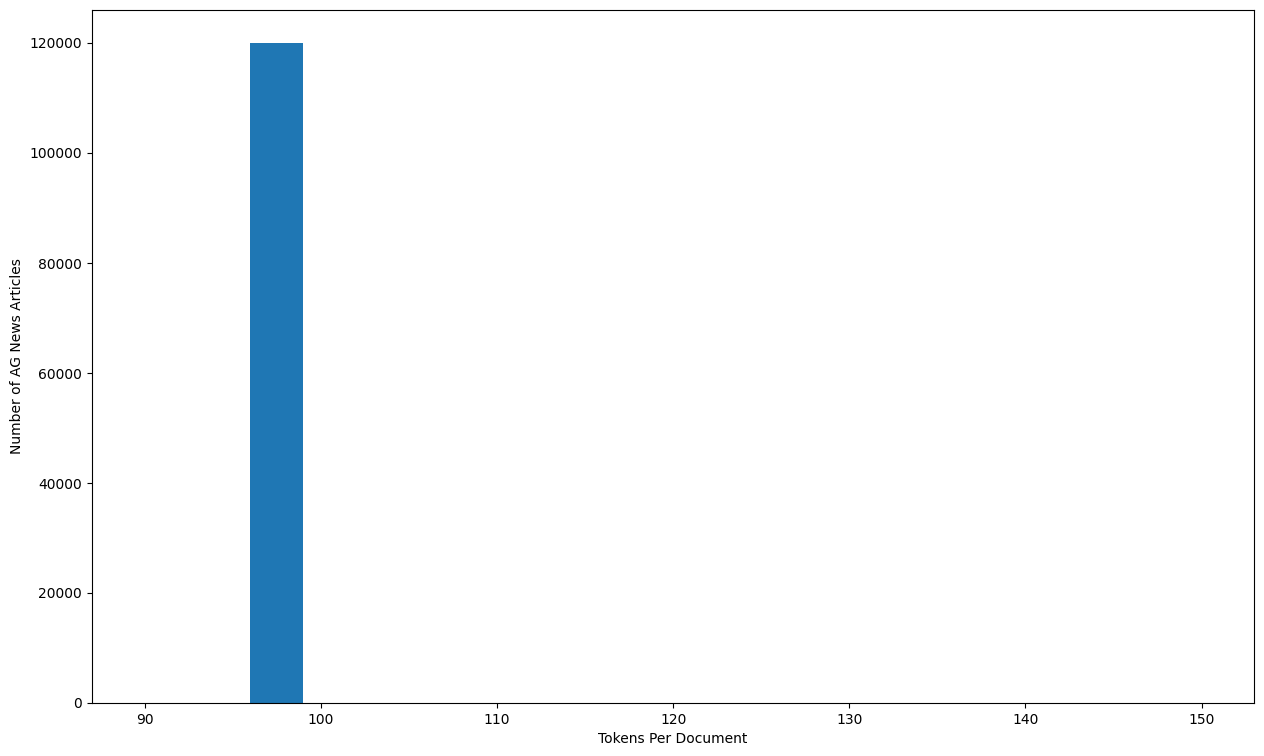

In [ ]:
plt.figure(figsize=(15,9))
plt.hist(doc_sizes, bins=20,range = (90,150))
plt.xlabel("Tokens Per Document")
plt.ylabel("Number of AG News Articles");

In [ ]:
def build_model(vectorizer, num_classes):
    model = models.Sequential([
        vectorizer,
        layers.Embedding(input_dim=vectorizer.vocabulary_size(), output_dim=64, mask_zero=True),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Determine accuracy with this vocab
start = time.time()

print("\n--- Training with stopwords removed ---")
model_with_stop_fixed = build_model(text_vectorization, 4)
model_with_stop_fixed.fit(ds_train.batch(32),  epochs=3)
stop = time.time()
print("Total time elapsed (s)", stop-start)


--- Training with stopwords removed ---
Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8518 - loss: 0.4734
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9369 - loss: 0.1859
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9567 - loss: 0.1259
Total time elapsed (s) 61.994484424591064


In [ ]:
test_loss, test_acc = model_with_stop_fixed.evaluate(ds_test.batch(32))
print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9045 - loss: 0.3415
Test accuracy: 0.9011842012405396


# EDA: Tweaking the vocabulary size



===== EDA for Vocabulary Size: 10 =====


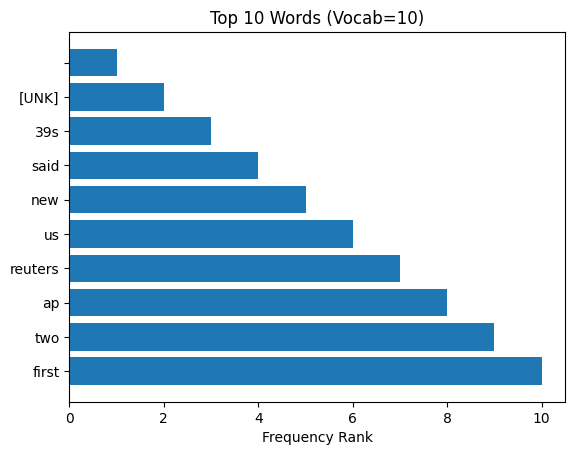

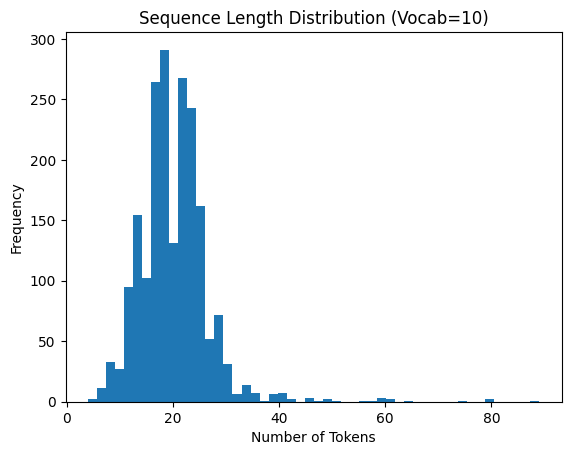

OOV Rate: 0.9534
Average Sequence Length: 20.18

===== EDA for Vocabulary Size: 100 =====


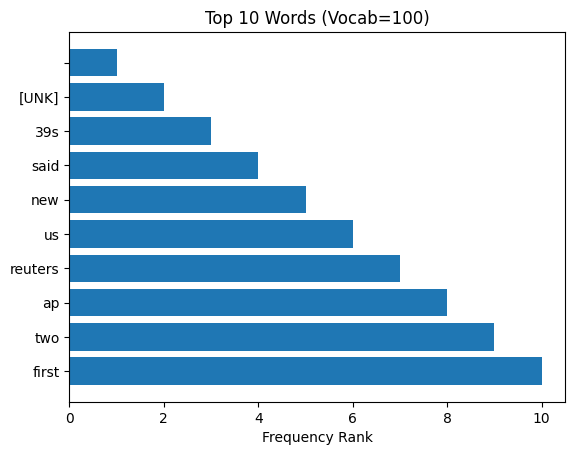

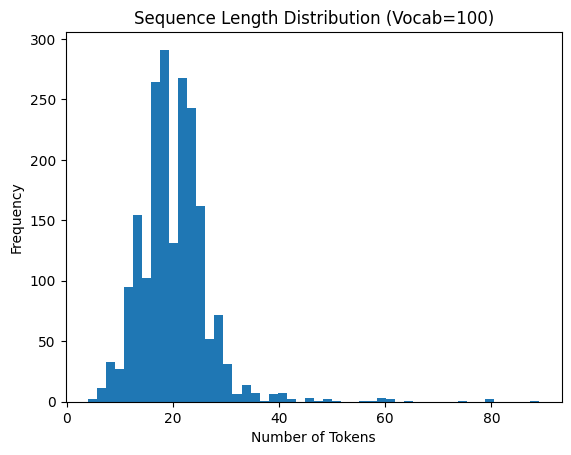

OOV Rate: 0.8171
Average Sequence Length: 20.18

===== EDA for Vocabulary Size: 1000 =====


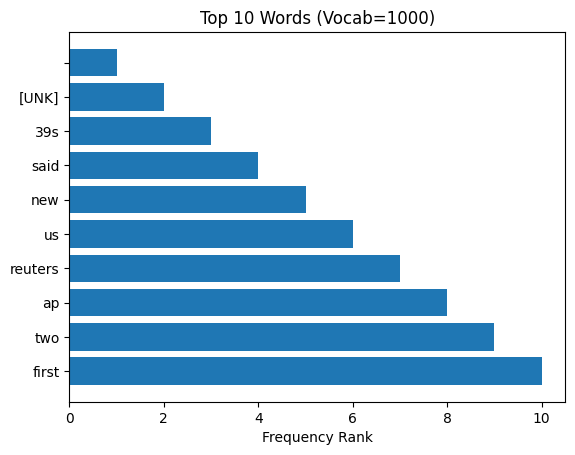

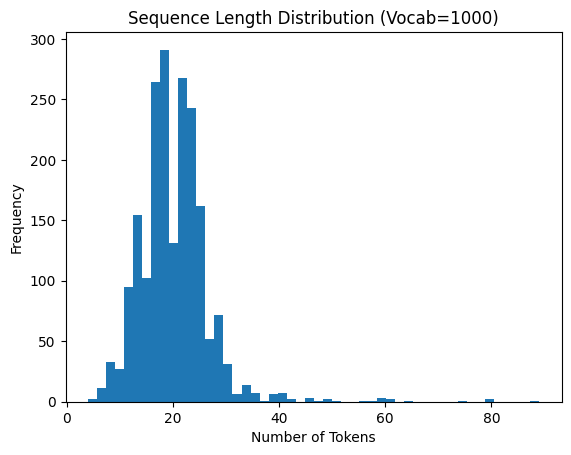

OOV Rate: 0.4906
Average Sequence Length: 20.18

===== EDA for Vocabulary Size: 10000 =====


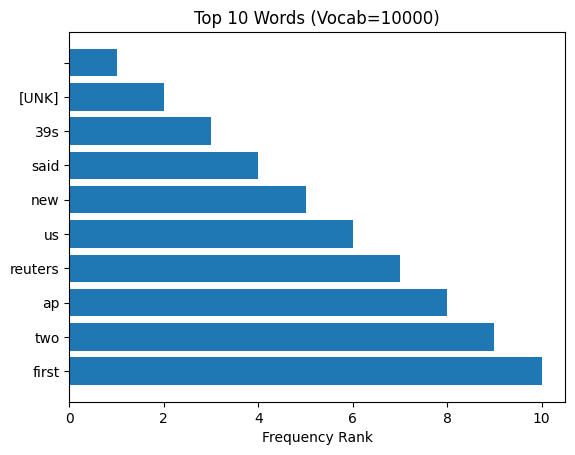

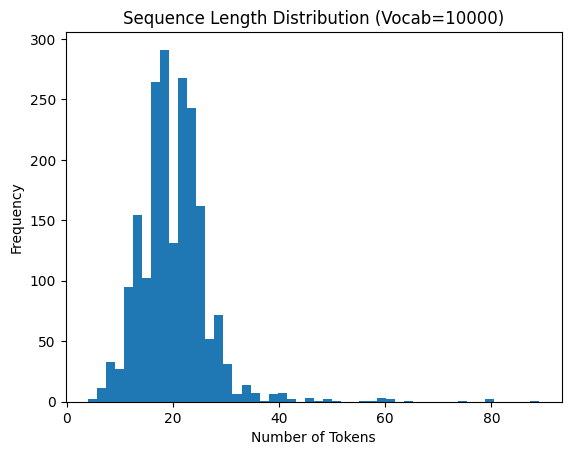

OOV Rate: 0.1194
Average Sequence Length: 20.18


In [ ]:
oov_rates = []
avg_lengths = []

VOCAB_SIZES = [10, 100, 1000, 10000]

for vsize in VOCAB_SIZES:
    print(f"\n===== EDA for Vocabulary Size: {vsize} =====")

    vectorizer = layers.TextVectorization(
        max_tokens=vsize,
        output_mode="int",
        standardize=custom_stopwords,
        output_sequence_length=fixed_len
    )
    vectorizer.adapt(train_text)

    # --- Top Words ---
    plot_top_words(vectorizer, vsize, top_n_words=10)

    # --- Sequence Lengths ---
    lengths = get_sequence_lengths(vectorizer, ds_train, sample_size=2000)
    plot_length_distribution(lengths, vsize)

    # # --- OOV Rate ---
    oov = compute_oov_rate(vectorizer, ds_train, sample_size=2000 )
    oov_rates.append(oov)

    # # --- Avg Length ---
    avg_len = np.mean(lengths)
    avg_lengths.append(avg_len)

    print(f"OOV Rate: {oov:.4f}")
    print(f"Average Sequence Length: {avg_len:.2f}")


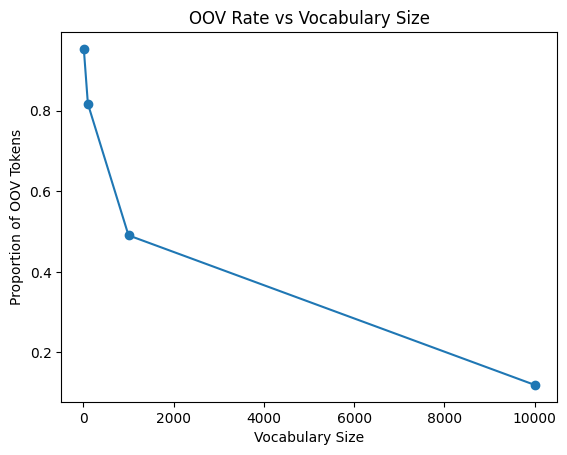

In [ ]:
plt.figure()
plt.plot(VOCAB_SIZES, oov_rates, marker='o')
plt.title("OOV Rate vs Vocabulary Size")
plt.xlabel("Vocabulary Size")
plt.ylabel("Proportion of OOV Tokens")
plt.show()

In [ ]:
models_vocab = {}
for vocab_size in VOCAB_SIZES:
    print(f"\n--- Training with vocab size = {vocab_size} ---")

    vectorizer = layers.TextVectorization(
        max_tokens=vocab_size,
        output_mode='int'
    )

    vectorizer.adapt(train_text)

    model = build_model(vectorizer, 4)

    model.fit(ds_train.batch(32), validation_data=ds_test.batch(32), epochs=3)

    models_vocab[vocab_size] = model

    test_loss, test_acc = model.evaluate(ds_test.batch(32))
    print(f"Test accuracy for vocab size {vocab_size}:", test_acc)




--- Training with vocab size = 10 ---
Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.3224 - loss: 1.3590 - val_accuracy: 0.3553 - val_loss: 1.3428
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.3595 - loss: 1.3360 - val_accuracy: 0.3533 - val_loss: 1.3430
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.3605 - loss: 1.3346 - val_accuracy: 0.3520 - val_loss: 1.3424
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3535 - loss: 1.3394
Test accuracy for vocab size 10: 0.35197368264198303

--- Training with vocab size = 100 ---
Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5515 - loss: 1.0526 - val_accuracy: 0.6275 - val_loss: 0.9148
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.6268 - loss: 0.9123 - val_accuracy: 0.6308 - val_loss: 0.9058
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.6290 - loss: 0.9053 - val_accuracy: 0.6317 - val_loss: 0.9002
238/238 ━━━━━

# Load data for Experiments

In [ ]:
dataset,info=\
tfds.load('ag_news_subset', with_info=True,  split=['train[:95%]','train[95%:]', 'test'],batch_size = 32
          , as_supervised=True)

train_ds, val_ds, test_ds = dataset
text_only_train_ds = train_ds.map(lambda x, y: x)

In [ ]:
def custom_stopwords(input_text):
    lowercase = tf.strings.lower(input_text)
    stripped_punct = tf.strings.regex_replace(lowercase
                                  ,'[%s]' % re.escape(string.punctuation)
                                  ,'')
    return tf.strings.regex_replace(stripped_punct, r'\b(' + r'|'.join(STOPWORDS) + r')\b\s*',"")

In [ ]:
nltk.download('stopwords',quiet=True)
STOPWORDS = stopwords.words("english")

In [ ]:
max_length = 96
max_tokens = 1000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
    standardize=custom_stopwords
)
text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
int_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

# Experiment 1
Simple RNN without Masking, 32 units

## Build and compile model

In [ ]:
import time
k.clear_session()


# Parameters
EMBED_DIM = 256
RNN_UNITS = 32

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM)(inputs)
x = layers.SimpleRNN(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=5
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 33s 8ms/step - accuracy: 0.2931 - loss: 1.3685 - val_accuracy: 0.3978 - val_loss: 1.2850
Epoch 2/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.4348 - loss: 1.2478 - val_accuracy: 0.4823 - val_loss: 1.1578
Epoch 3/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.5189 - loss: 1.0887 - val_accuracy: 0.5357 - val_loss: 1.0223
Epoch 4/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.5695 - loss: 0.9429 - val_accuracy: 0.4638 - val_loss: 1.1737
Epoch 5/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.5247 - loss: 1.0420 - val_accuracy: 0.6160 - val_loss: 0.8709
Total time elapsed (s) 139.7720170021057


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,894 (3.22 MB)

 Trainable params: 280,964 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 561,930 (2.14 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7552 - loss: 0.6617
Test accuracy: 0.7517105340957642


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot Metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.320,1.334,0.468,1.094
1,0.618,0.877,0.721,0.742
2,0.755,0.688,0.780,0.644
3,0.771,0.659,0.791,0.631
4,0.775,0.648,0.755,0.668


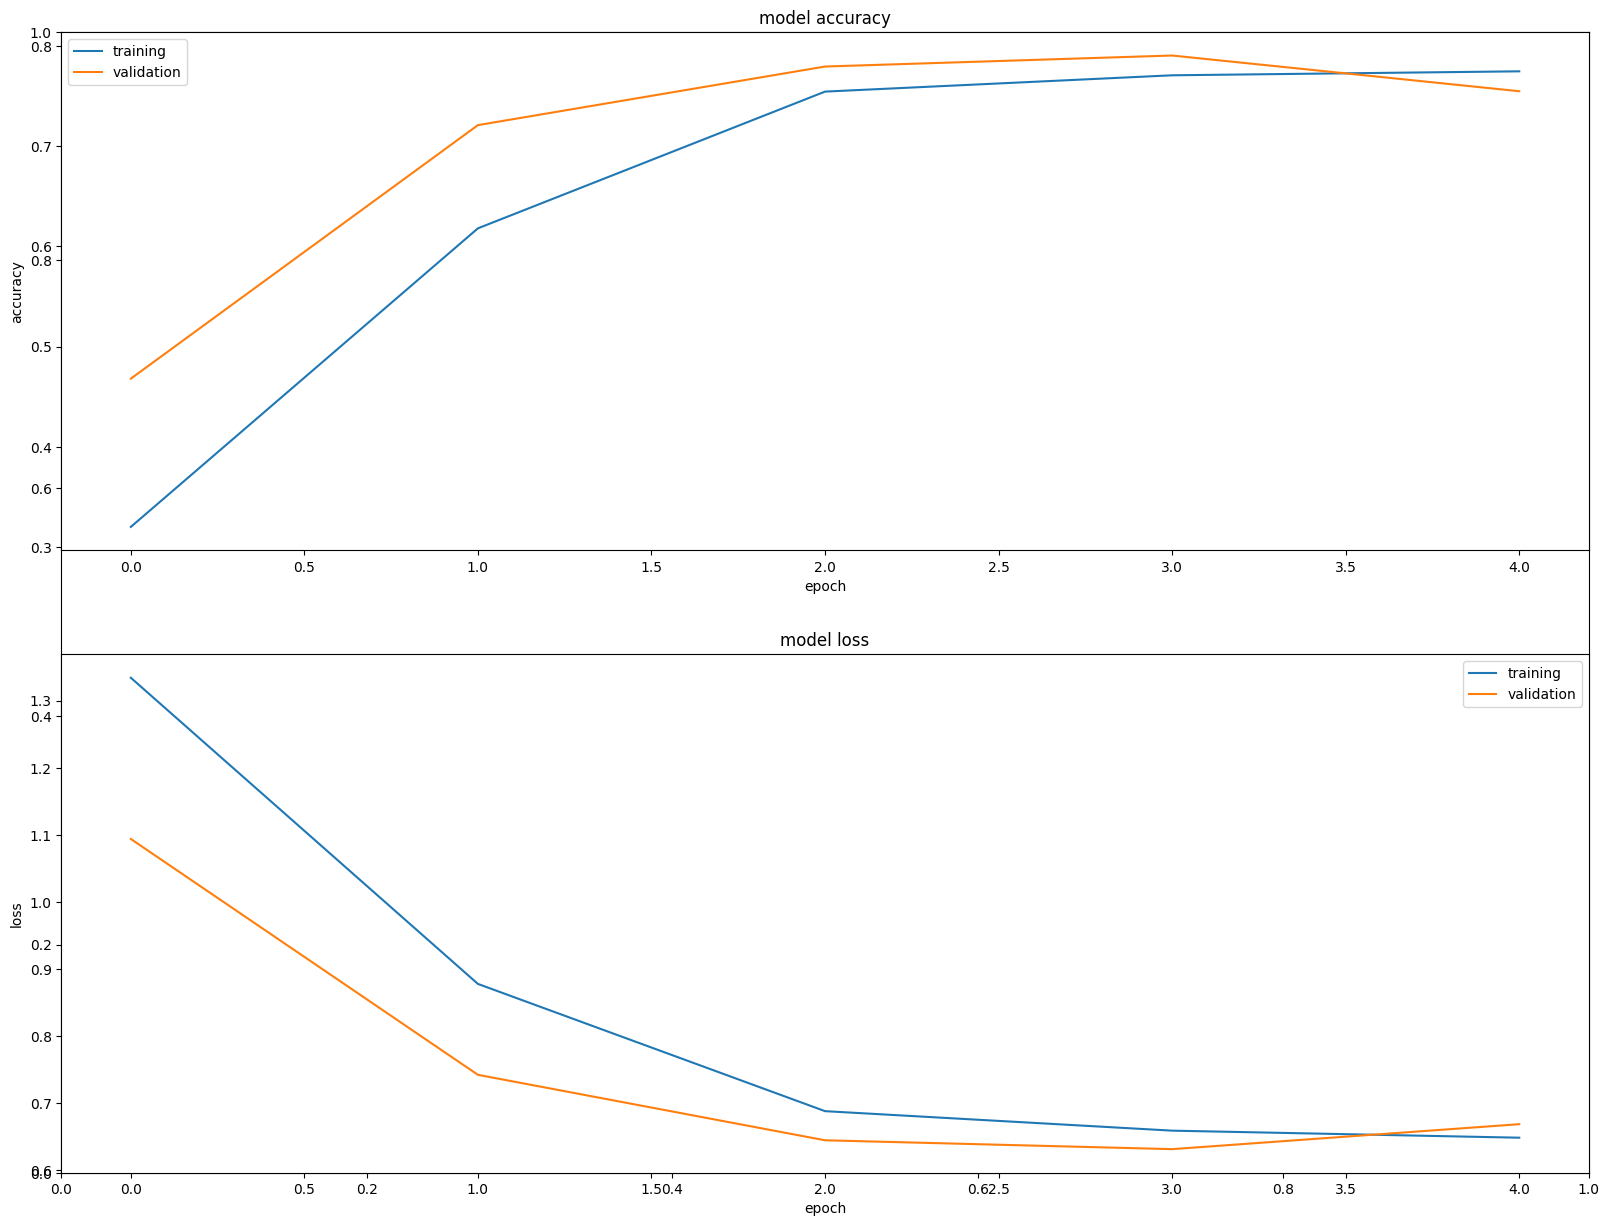

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.66      0.73      1900
           1       0.81      0.93      0.87      1900
           2       0.81      0.62      0.70      1900
           3       0.63      0.80      0.70      1900

    accuracy                           0.75      7600
   macro avg       0.76      0.75      0.75      7600
weighted avg       0.76      0.75      0.75      7600

Accuracy Score: 0.7517105263157895
Root Mean Square Error: 0.9196681323630881


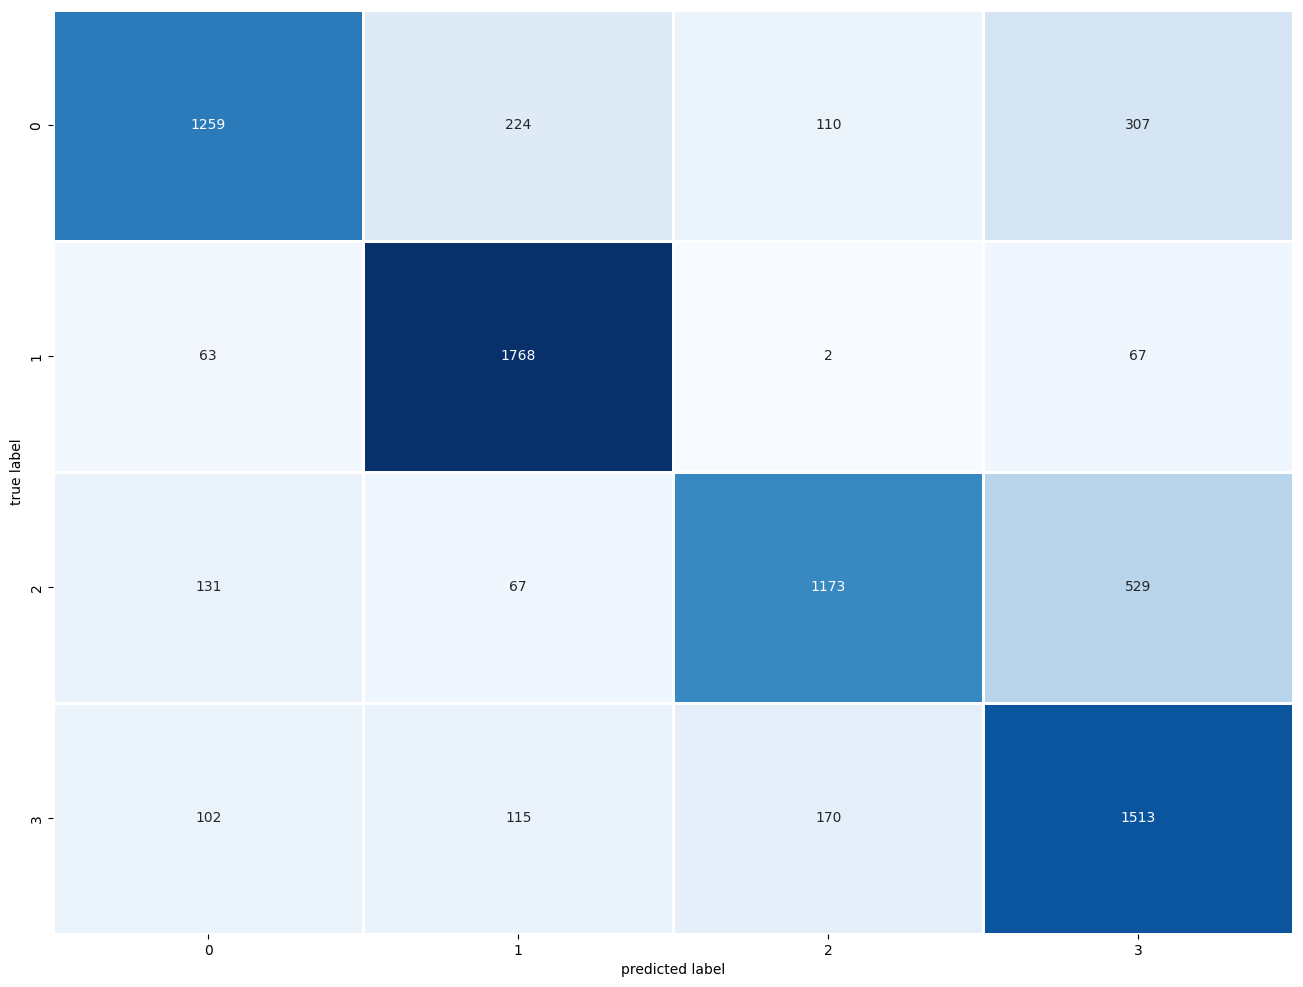

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 2
Simple RNN with Masking, 32 units

## Build and compile model

In [ ]:
import time
k.clear_session()


# Parameters
EMBED_DIM = 256
RNN_UNITS = 32

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)
x = layers.SimpleRNN(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=5
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.7339 - loss: 0.6696 - val_accuracy: 0.8455 - val_loss: 0.4408
Epoch 2/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8406 - loss: 0.4471 - val_accuracy: 0.8328 - val_loss: 0.4848
Epoch 3/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8515 - loss: 0.4155 - val_accuracy: 0.8302 - val_loss: 0.4910
Epoch 4/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8607 - loss: 0.3944 - val_accuracy: 0.8363 - val_loss: 0.4911
Epoch 5/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8651 - loss: 0.3784 - val_accuracy: 0.8357 - val_loss: 0.4945
Total time elapsed (s) 145.5354564189911


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 32)        │      9,248 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 802,862 (3.06 MB)

 Trainable params: 267,620 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 535,242 (2.04 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8328 - loss: 0.4870
Test accuracy: 0.8278947472572327


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot Metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.805,0.531,0.845,0.441
1,0.844,0.440,0.833,0.485
2,0.855,0.410,0.830,0.491
3,0.862,0.391,0.836,0.491
4,0.866,0.377,0.836,0.494


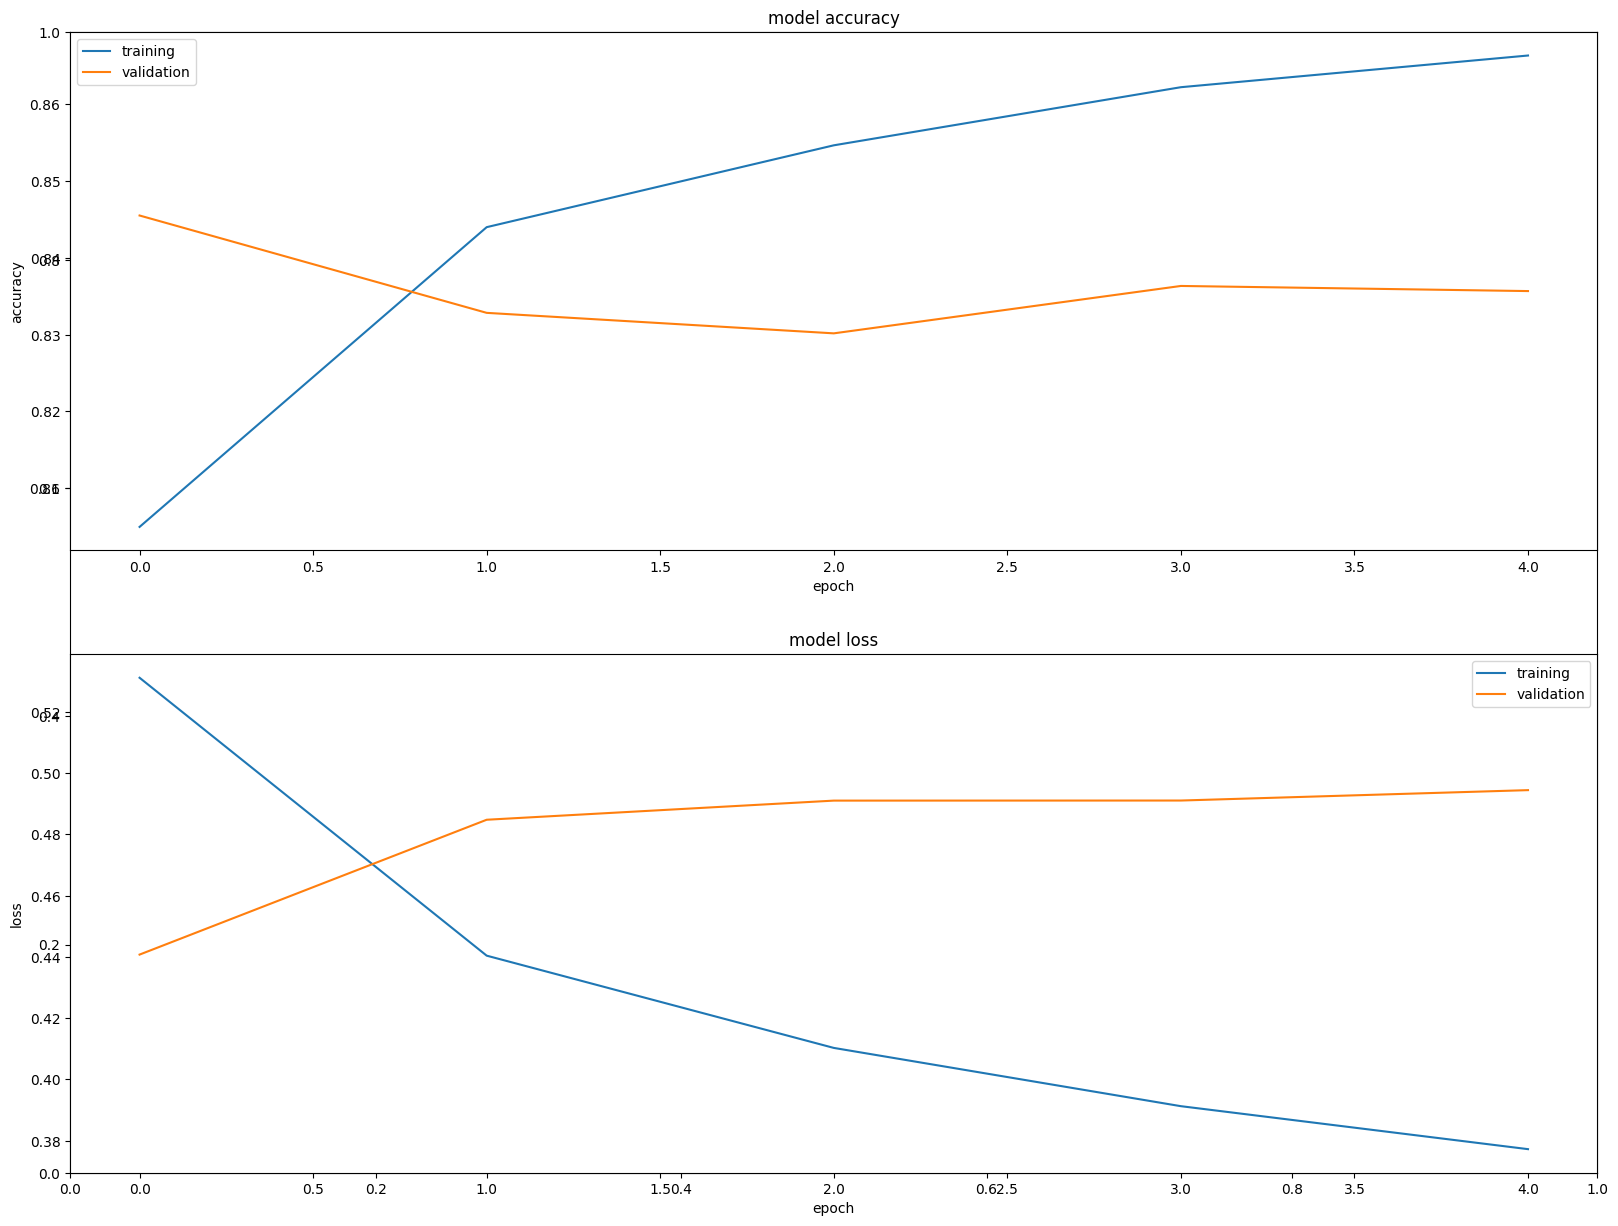

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1900
           1       0.89      0.92      0.90      1900
           2       0.86      0.71      0.78      1900
           3       0.75      0.83      0.79      1900

    accuracy                           0.83      7600
   macro avg       0.83      0.83      0.83      7600
weighted avg       0.83      0.83      0.83      7600

Accuracy Score: 0.8278947368421052
Root Mean Square Error: 0.7456011350793258


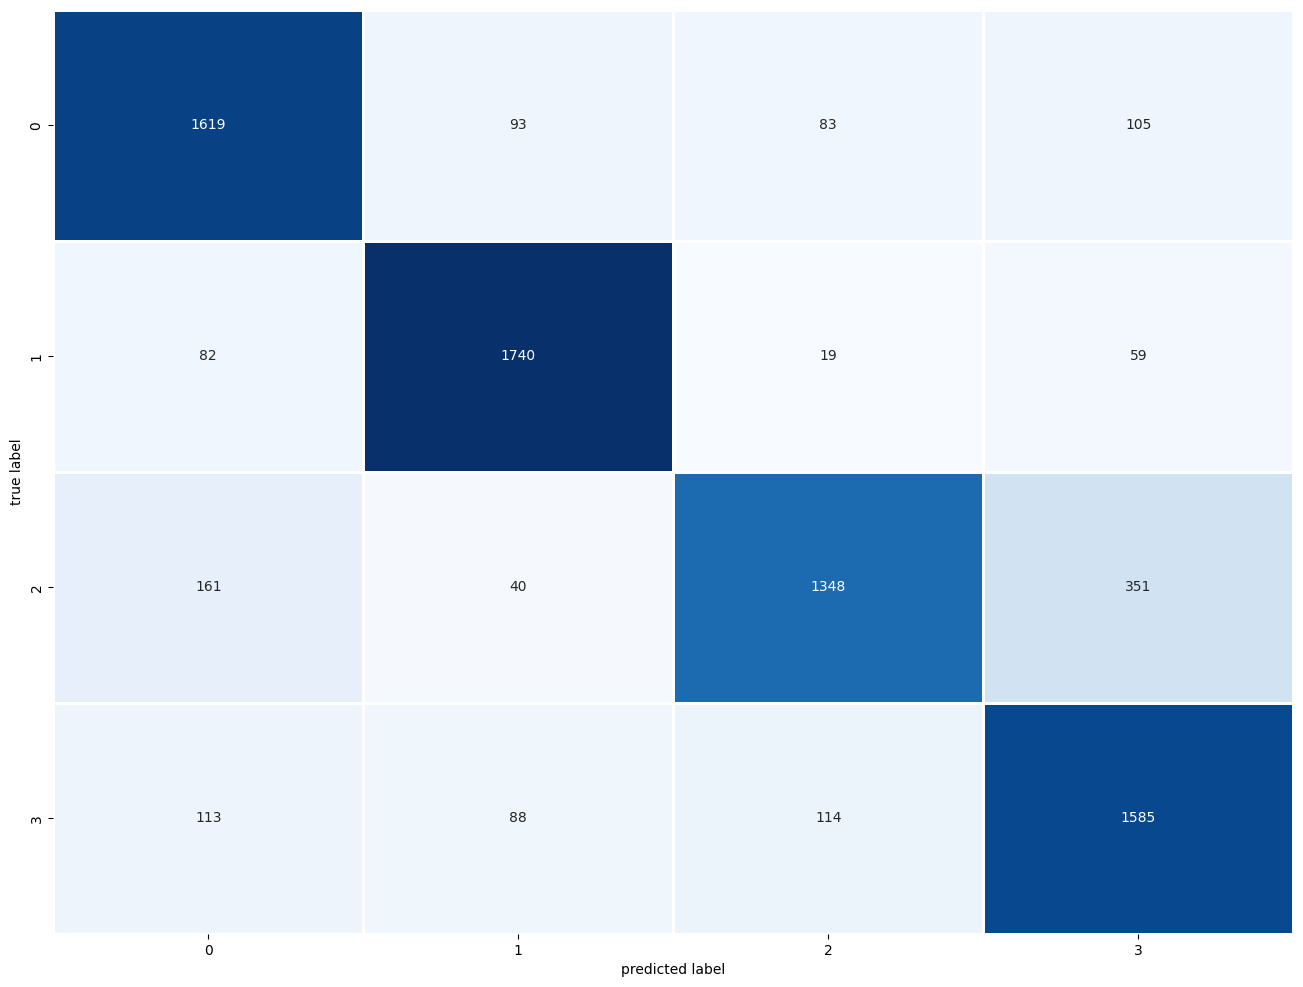

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 3
Simple RNN with Masking, 64 units

## Build and compile model

In [ ]:
import time
k.clear_session()


# Parameters
EMBED_DIM = 256
RNN_UNITS = 64

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)
x = layers.SimpleRNN(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=5
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.7264 - loss: 0.6663 - val_accuracy: 0.8430 - val_loss: 0.4498
Epoch 2/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8364 - loss: 0.4569 - val_accuracy: 0.8447 - val_loss: 0.4456
Epoch 3/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8489 - loss: 0.4229 - val_accuracy: 0.8397 - val_loss: 0.4714
Epoch 4/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8577 - loss: 0.3988 - val_accuracy: 0.8387 - val_loss: 0.4689
Epoch 5/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.8621 - loss: 0.3840 - val_accuracy: 0.8333 - val_loss: 0.4842
Total time elapsed (s) 148.08399724960327


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │     20,544 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 842,894 (3.22 MB)

 Trainable params: 280,964 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 561,930 (2.14 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8356 - loss: 0.4727
Test accuracy: 0.8349999785423279


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot Metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.800,0.538,0.843,0.450
1,0.840,0.450,0.845,0.446
2,0.851,0.420,0.840,0.471
3,0.858,0.398,0.839,0.469
4,0.864,0.382,0.833,0.484


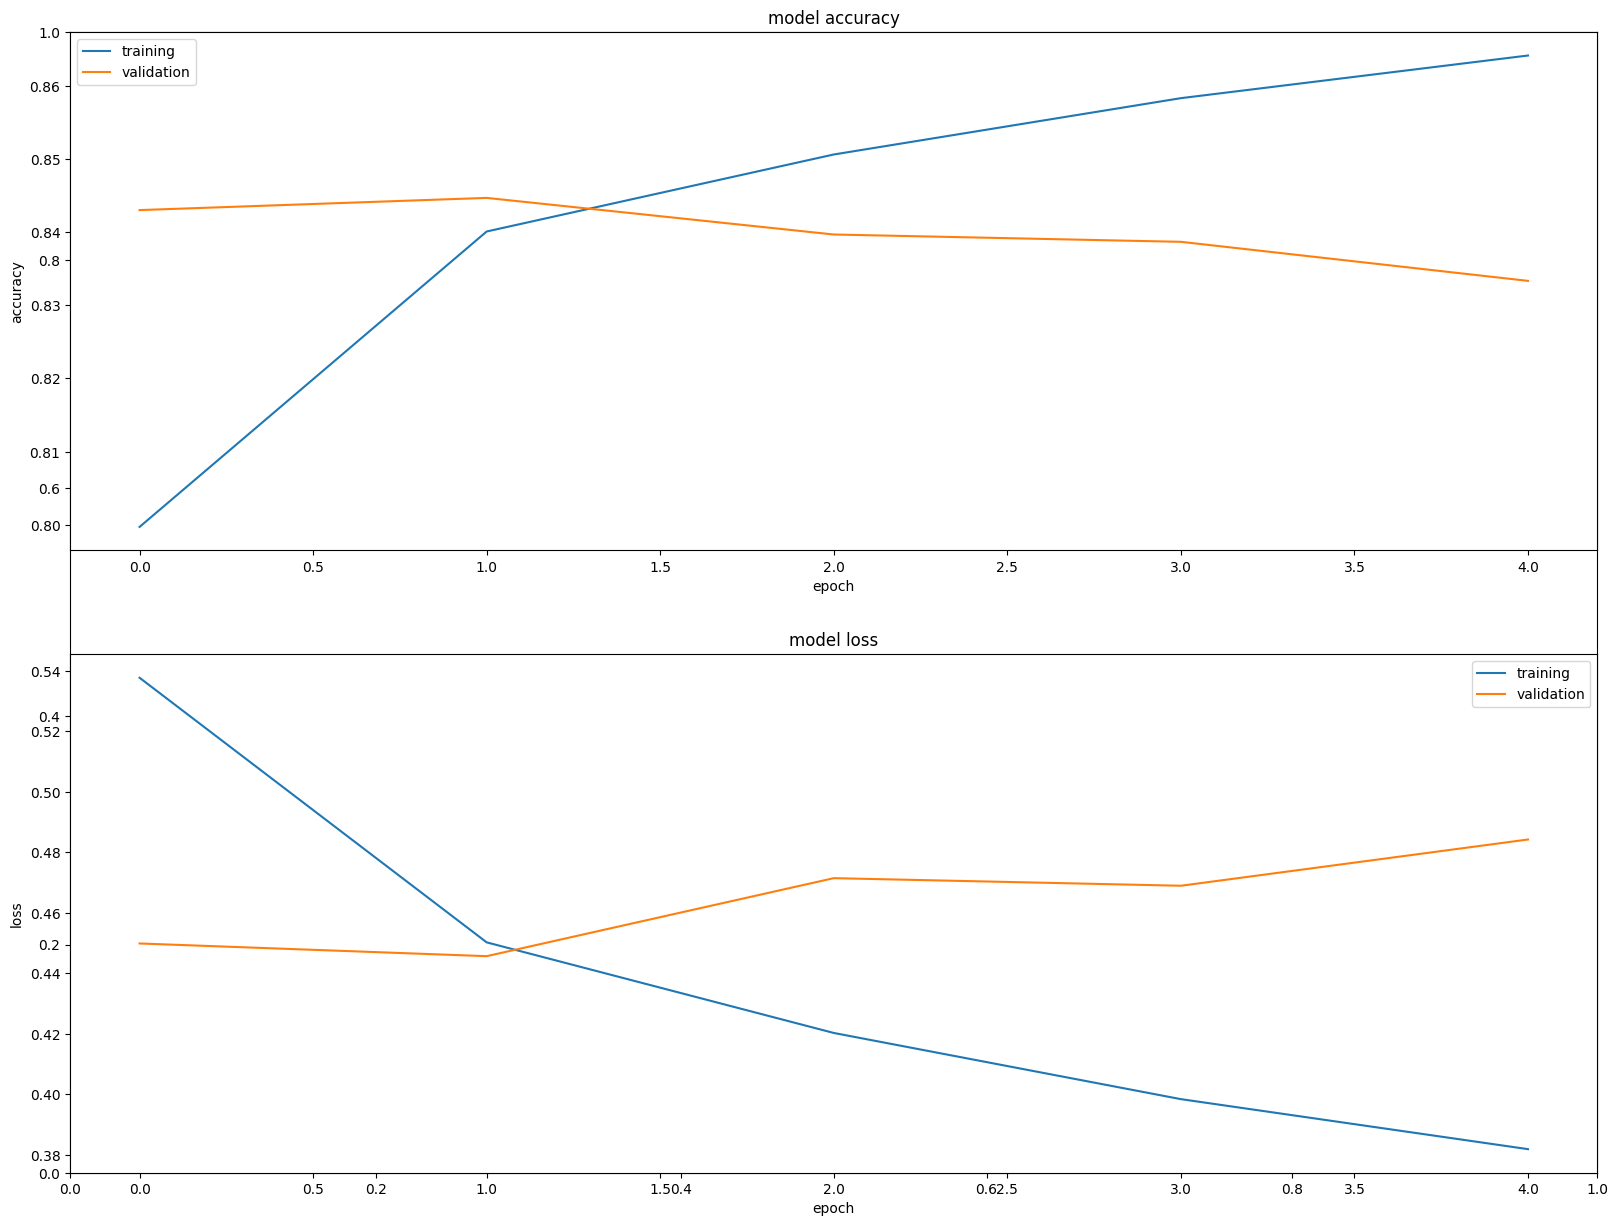

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1900
           1       0.90      0.92      0.91      1900
           2       0.82      0.77      0.80      1900
           3       0.80      0.78      0.79      1900

    accuracy                           0.83      7600
   macro avg       0.83      0.84      0.83      7600
weighted avg       0.83      0.83      0.83      7600

Accuracy Score: 0.835
Root Mean Square Error: 0.7338614525773564


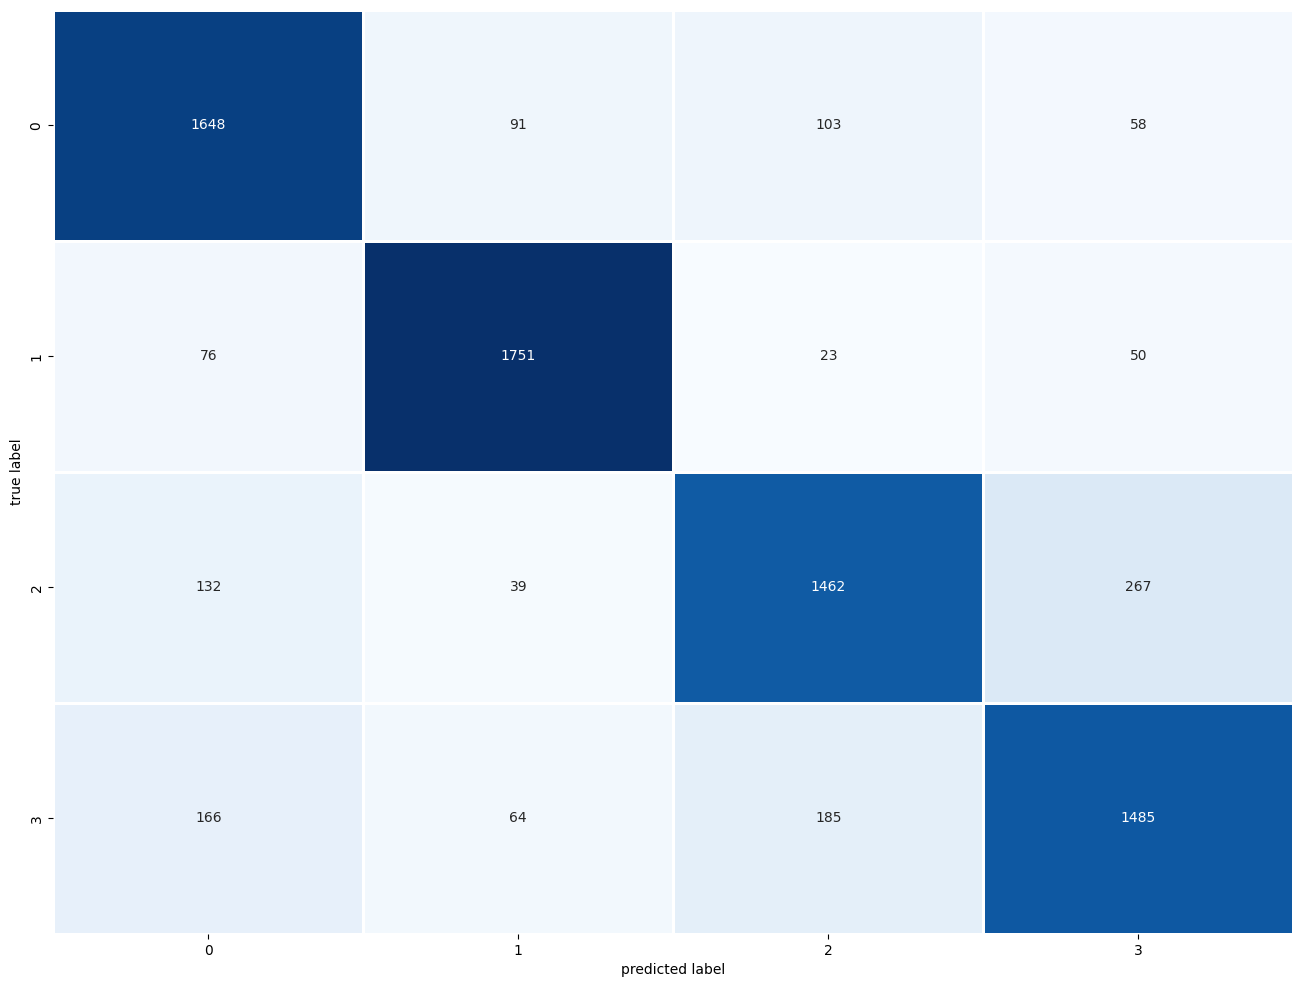

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 4
Simple RNN with Masking, 64 units, with Early Stopping

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
BATCH_SIZE = 32

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)
x = layers.SimpleRNN(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("RNN.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.7588 - loss: 0.6264 - val_accuracy: 0.8427 - val_loss: 0.4576
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8383 - loss: 0.4559 - val_accuracy: 0.8460 - val_loss: 0.4469
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8484 - loss: 0.4273 - val_accuracy: 0.8465 - val_loss: 0.4521
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8564 - loss: 0.4038 - val_accuracy: 0.8393 - val_loss: 0.4815
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8607 - loss: 0.3929 - val_accuracy: 0.8400 - val_loss: 0.4729
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8700 - loss: 0.3702 - val_accuracy: 0.8362 - val_loss: 0.4961
Total time elapsed (s) 177.75388860702515


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │     20,544 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 842,894 (3.22 MB)

 Trainable params: 280,964 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 561,930 (2.14 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8313 - loss: 0.5193
Test accuracy: 0.8311842083930969


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot Metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
1,0.841,0.450,0.846,0.447
2,0.850,0.424,0.846,0.452
3,0.858,0.401,0.839,0.481
4,0.863,0.387,0.840,0.473
5,0.868,0.373,0.836,0.496


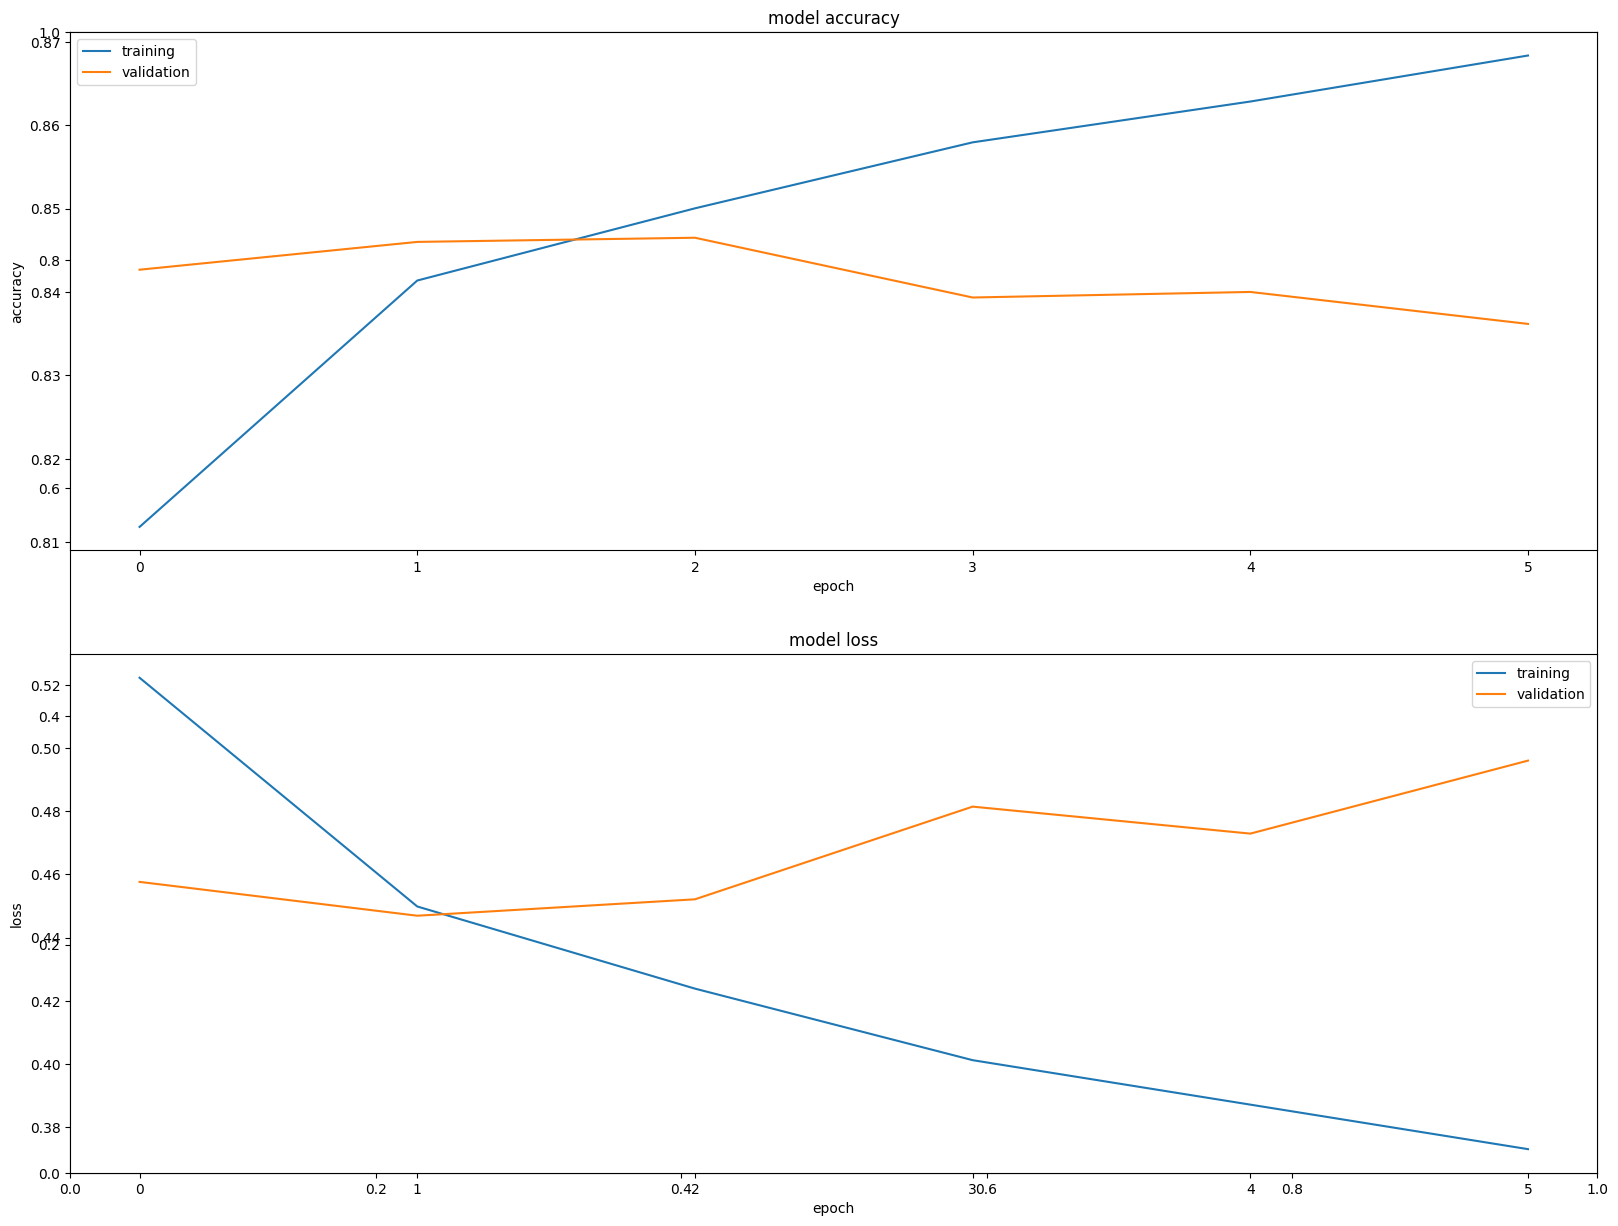

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1900
           1       0.92      0.90      0.91      1900
           2       0.80      0.81      0.80      1900
           3       0.82      0.74      0.78      1900

    accuracy                           0.83      7600
   macro avg       0.83      0.83      0.83      7600
weighted avg       0.83      0.83      0.83      7600

Accuracy Score: 0.8311842105263157
Root Mean Square Error: 0.7450715260613362


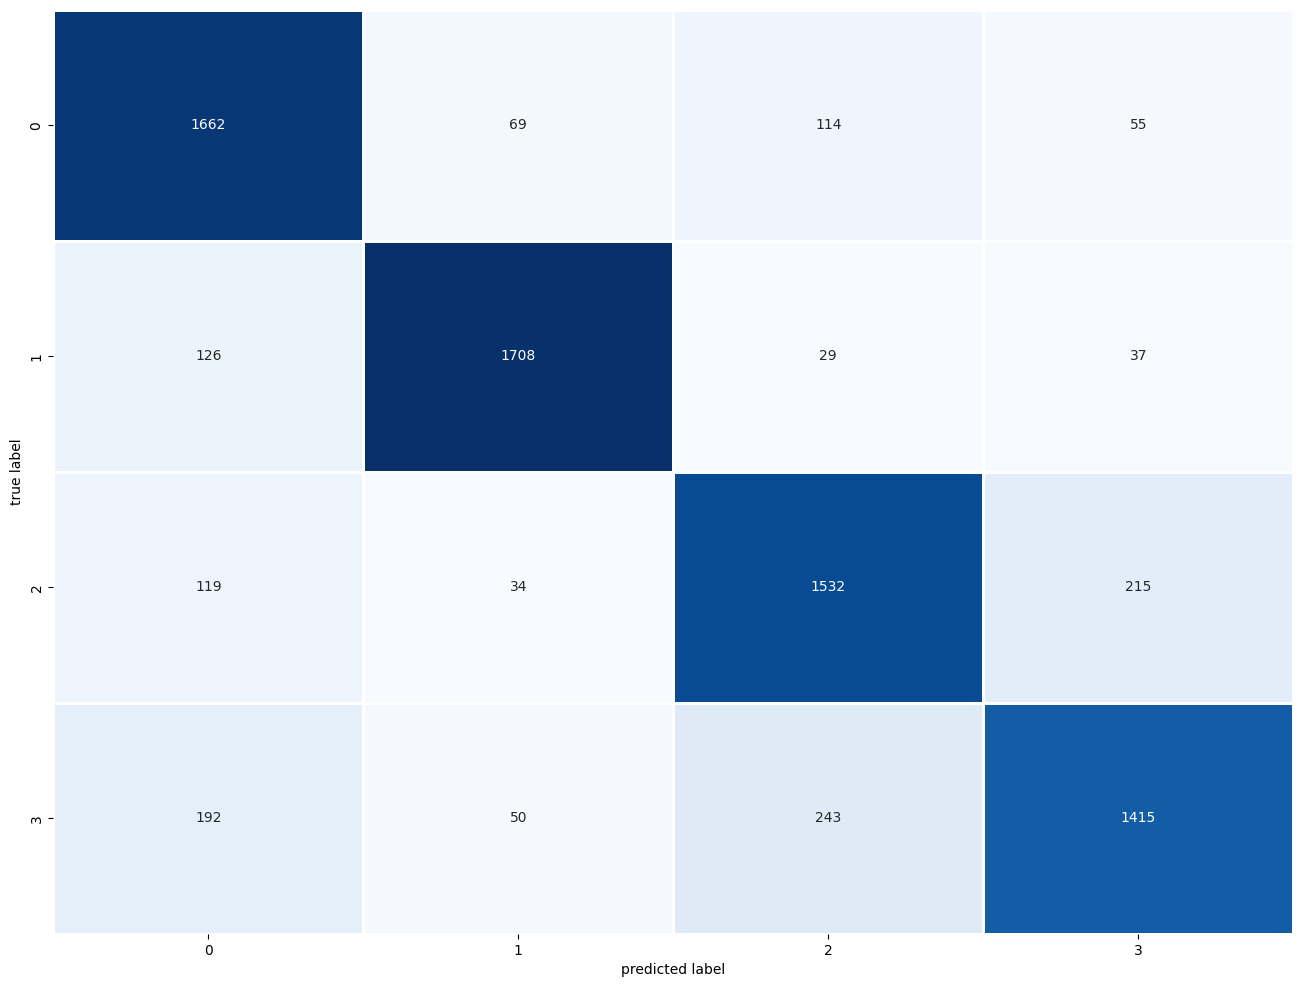

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 5
Simple RNN with masking, 64 units, Early Stopping & L2 Regularization

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
L2_VALUE = 0.001

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True
                             ,embeddings_regularizer=regularizers.l2(L2_VALUE))(inputs)
x = layers.SimpleRNN(RNN_UNITS,
                     kernel_regularizer=regularizers.l2(L2_VALUE),
                    recurrent_regularizer=regularizers.l2(L2_VALUE),
                    bias_regularizer=regularizers.l2(L2_VALUE))(embedded)
x =  layers.Dense(64,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="relu")(x)
outputs = layers.Dense(4,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("RNN.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)



stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.7412 - loss: 0.9158 - val_accuracy: 0.8347 - val_loss: 0.5870
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8301 - loss: 0.5864 - val_accuracy: 0.8470 - val_loss: 0.5323
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8373 - loss: 0.5454 - val_accuracy: 0.8475 - val_loss: 0.5137
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8405 - loss: 0.5295 - val_accuracy: 0.8450 - val_loss: 0.5072
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8420 - loss: 0.5205 - val_accuracy: 0.8457 - val_loss: 0.5051
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.8425 - loss: 0.5151 - val_accuracy: 0.8470 - val_loss: 0.5015
Total time elapsed (s) 177.99425077438354


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │     20,544 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 842,894 (3.22 MB)

 Trainable params: 280,964 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 561,930 (2.14 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8415 - loss: 0.5163
Test accuracy: 0.8417105078697205


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

##  Plot Metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
1,0.833,0.573,0.847,0.532
2,0.838,0.541,0.848,0.514
3,0.841,0.528,0.845,0.507
4,0.842,0.520,0.846,0.505
5,0.843,0.514,0.847,0.502


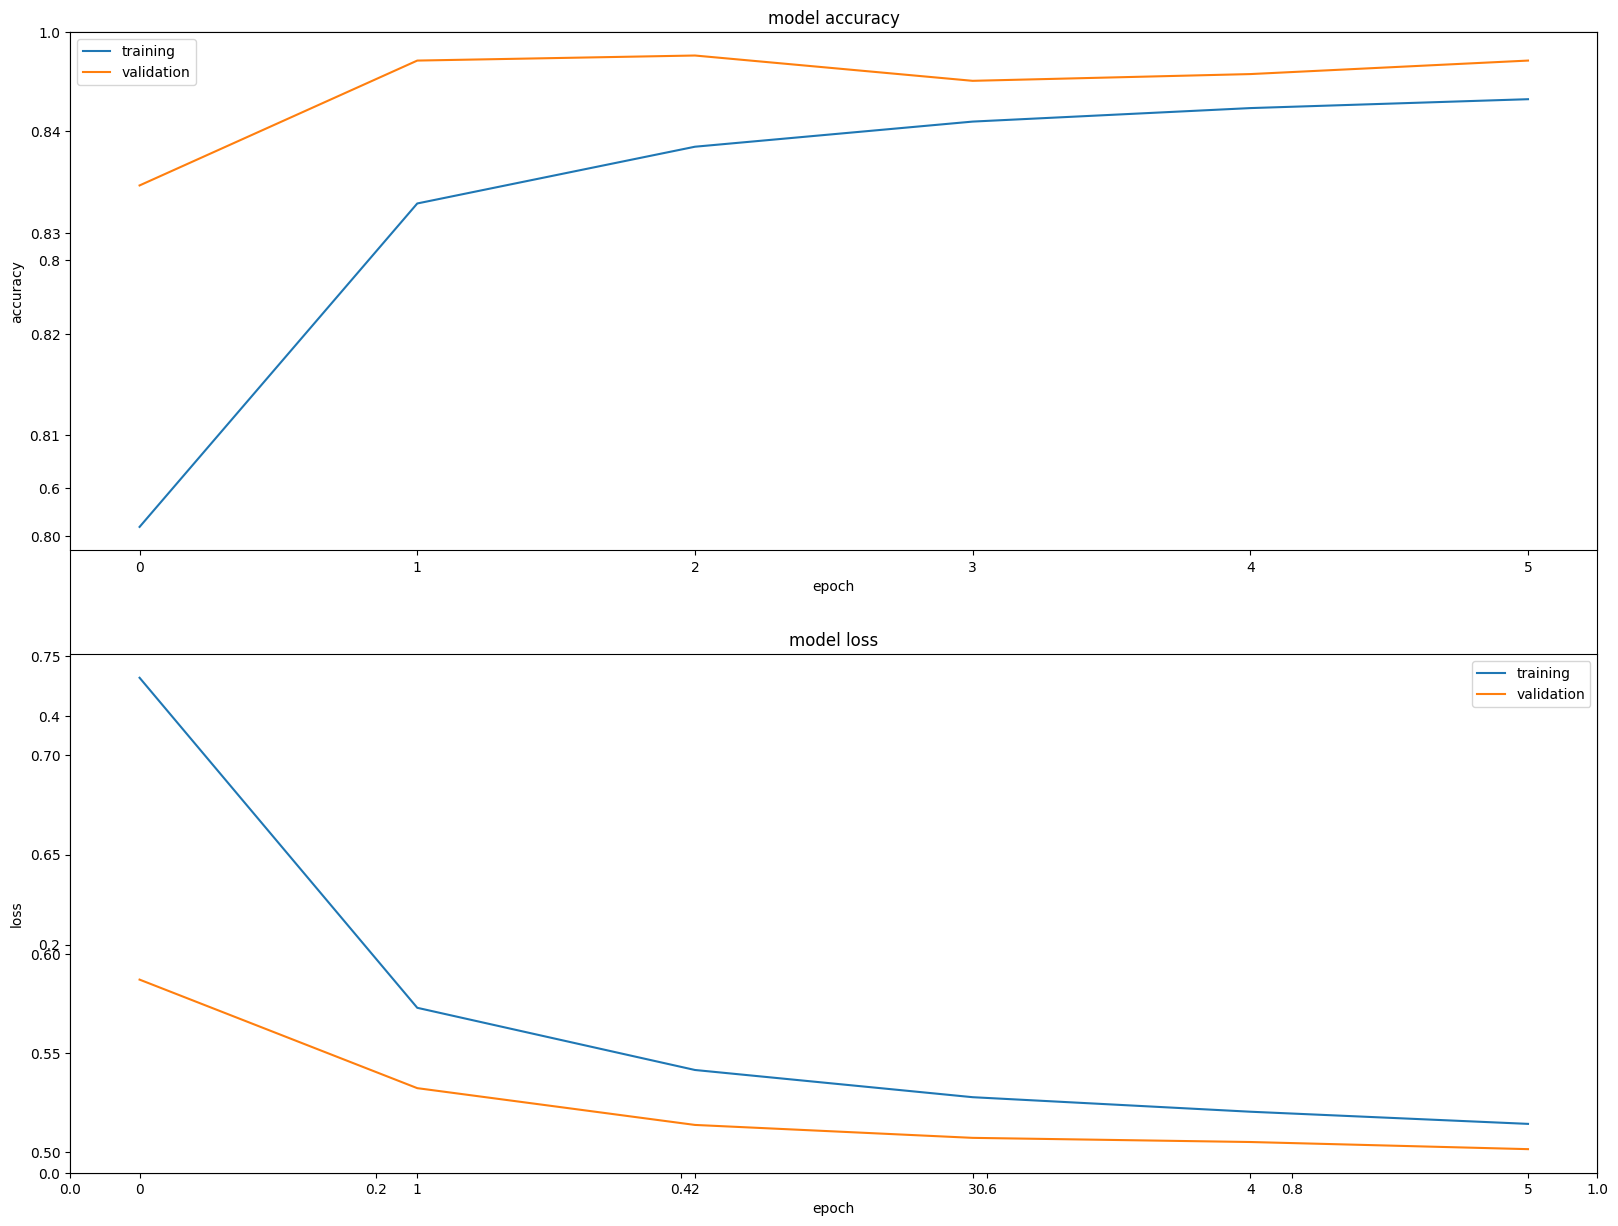

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1900
           1       0.93      0.89      0.91      1900
           2       0.84      0.78      0.81      1900
           3       0.78      0.82      0.80      1900

    accuracy                           0.84      7600
   macro avg       0.84      0.84      0.84      7600
weighted avg       0.84      0.84      0.84      7600

Accuracy Score: 0.8417105263157895
Root Mean Square Error: 0.7158910531638176


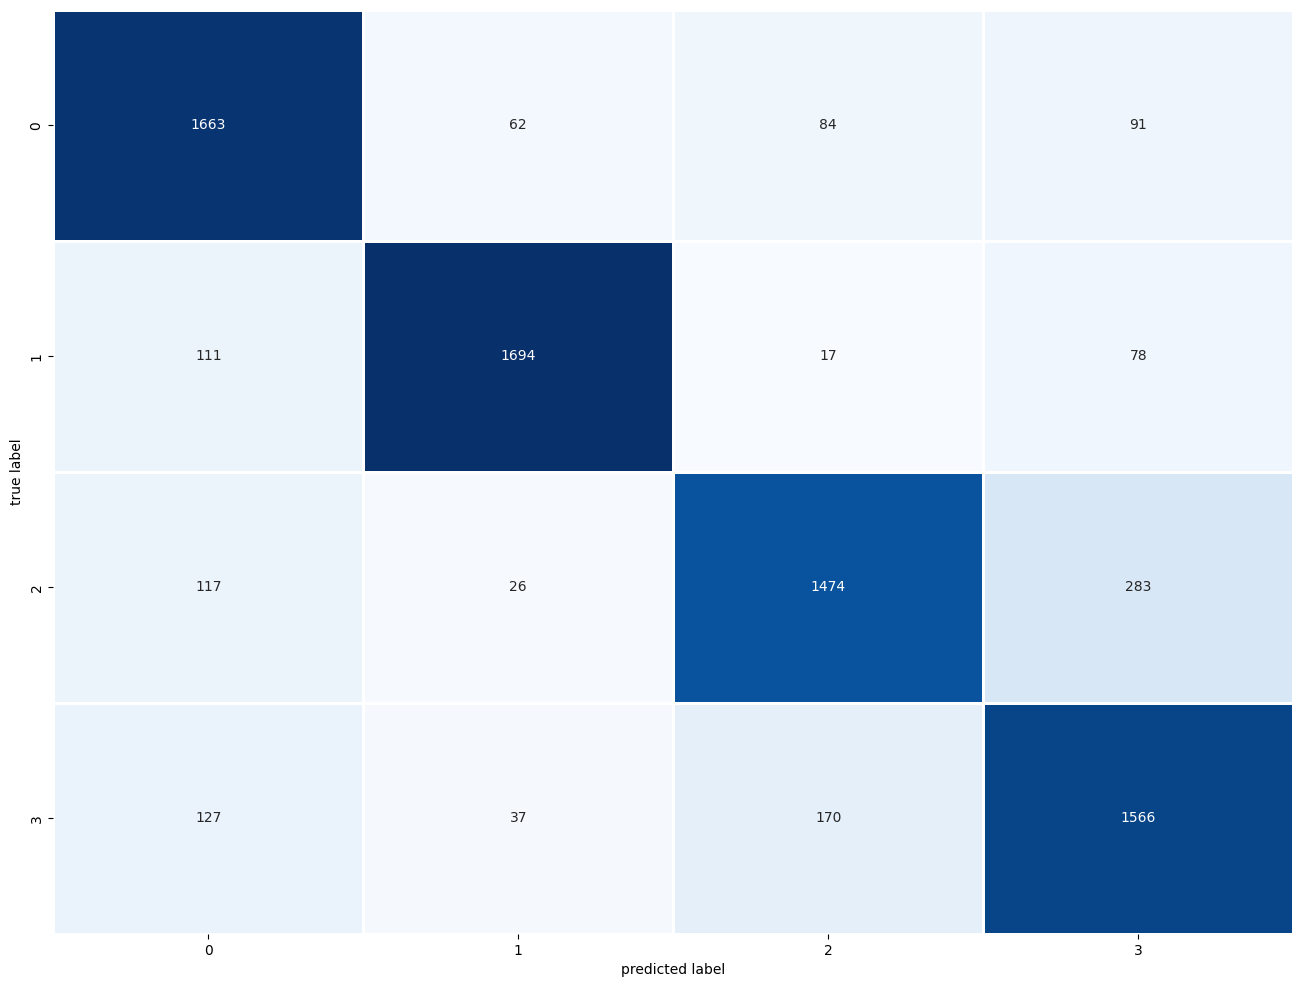

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 6
Bidirectional SimpleRNN with masking, 64 units, Early Stopping, L2 Regularization

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
L2_VALUE = 0.001

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True
                             ,embeddings_regularizer=regularizers.l2(L2_VALUE))(inputs)
x = layers.Bidirectional(layers.SimpleRNN(RNN_UNITS,
                     kernel_regularizer=regularizers.l2(L2_VALUE),
                    recurrent_regularizer=regularizers.l2(L2_VALUE),
                    bias_regularizer=regularizers.l2(L2_VALUE)))(embedded)
x =  layers.Dense(64,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="relu")(x)
outputs = layers.Dense(4,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("RNN.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)



stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 60s 15ms/step - accuracy: 0.7633 - loss: 0.9566 - val_accuracy: 0.8358 - val_loss: 0.5867
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8351 - loss: 0.5772 - val_accuracy: 0.8473 - val_loss: 0.5299
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8414 - loss: 0.5327 - val_accuracy: 0.8517 - val_loss: 0.5105
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8450 - loss: 0.5159 - val_accuracy: 0.8505 - val_loss: 0.5041
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8458 - loss: 0.5090 - val_accuracy: 0.8512 - val_loss: 0.5037
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - accuracy: 0.8465 - loss: 0.5051 - val_accuracy: 0.8510 - val_loss: 0.5039
Total time elapsed (s) 309.04681372642517


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     41,088 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 916,814 (3.50 MB)

 Trainable params: 305,604 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 611,210 (2.33 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8453 - loss: 0.5150
Test accuracy: 0.8455263376235962


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

##  Plot Metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
1,0.838,0.562,0.847,0.530
2,0.843,0.528,0.852,0.510
3,0.845,0.515,0.850,0.504
4,0.846,0.509,0.851,0.504
5,0.847,0.506,0.851,0.504


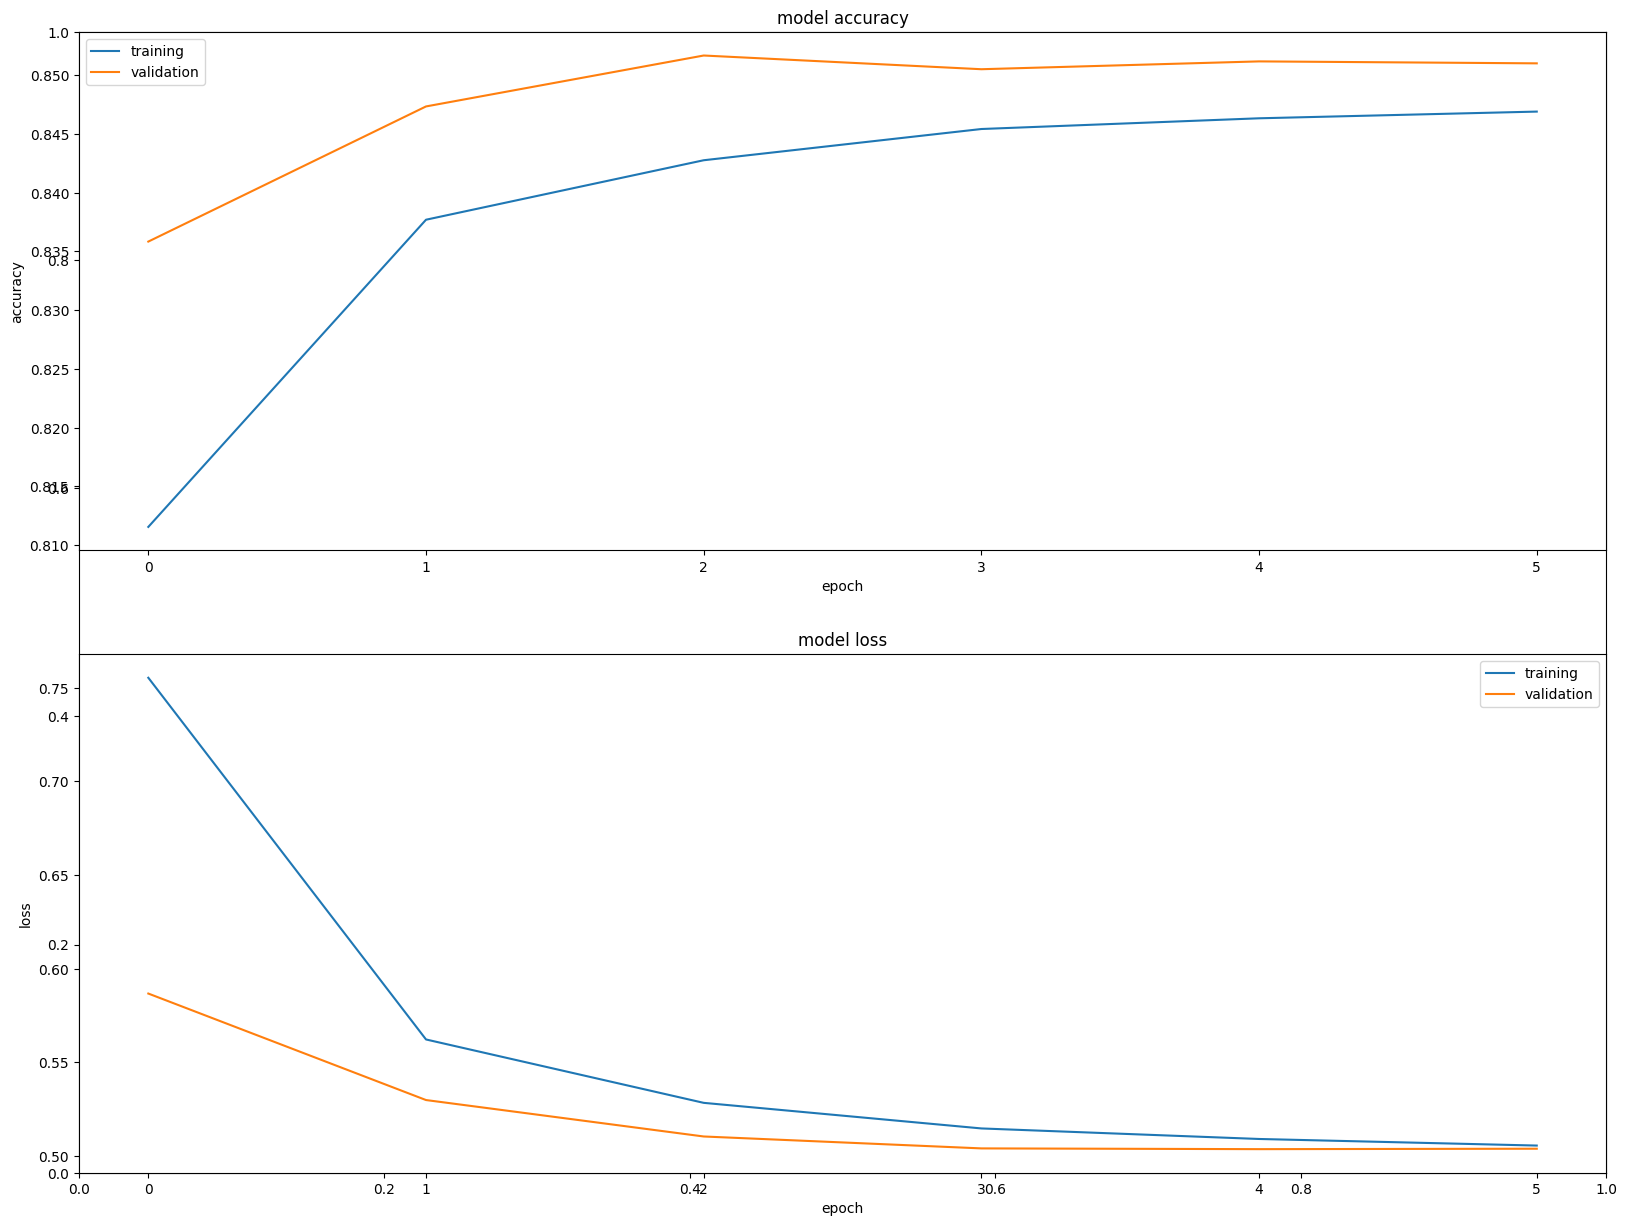

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1900
           1       0.94      0.89      0.91      1900
           2       0.86      0.77      0.81      1900
           3       0.77      0.85      0.81      1900

    accuracy                           0.85      7600
   macro avg       0.85      0.85      0.85      7600
weighted avg       0.85      0.85      0.85      7600

Accuracy Score: 0.8455263157894737
Root Mean Square Error: 0.717359925809837


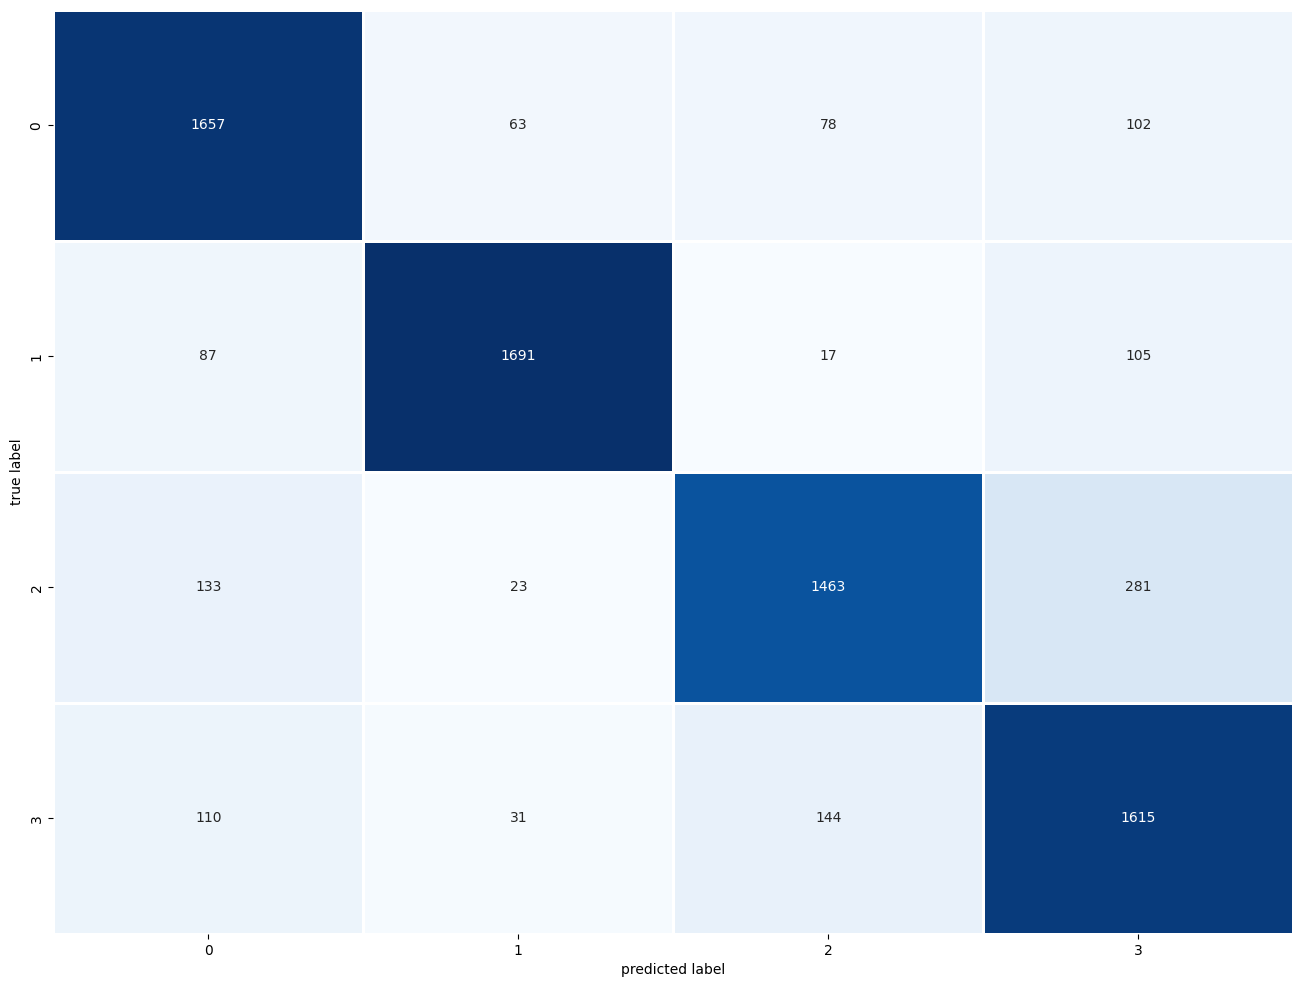

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 7
LSTM, masking, 32 units

## Build Model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 32

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)
x = layers.LSTM(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=5
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.7853 - loss: 0.5657 - val_accuracy: 0.8598 - val_loss: 0.4005
Epoch 2/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8564 - loss: 0.3939 - val_accuracy: 0.8625 - val_loss: 0.3849
Epoch 3/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8659 - loss: 0.3621 - val_accuracy: 0.8647 - val_loss: 0.3823
Epoch 4/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8748 - loss: 0.3348 - val_accuracy: 0.8652 - val_loss: 0.3876
Epoch 5/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8847 - loss: 0.3106 - val_accuracy: 0.8625 - val_loss: 0.4018
Total time elapsed (s) 116.03441452980042


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     36,992 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 886,094 (3.38 MB)

 Trainable params: 295,364 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 590,730 (2.25 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss: 0.3937
Test accuracy: 0.862500011920929


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.831,0.464,0.860,0.400
1,0.859,0.388,0.863,0.385
2,0.868,0.357,0.865,0.382
3,0.878,0.330,0.865,0.388
4,0.887,0.306,0.863,0.402


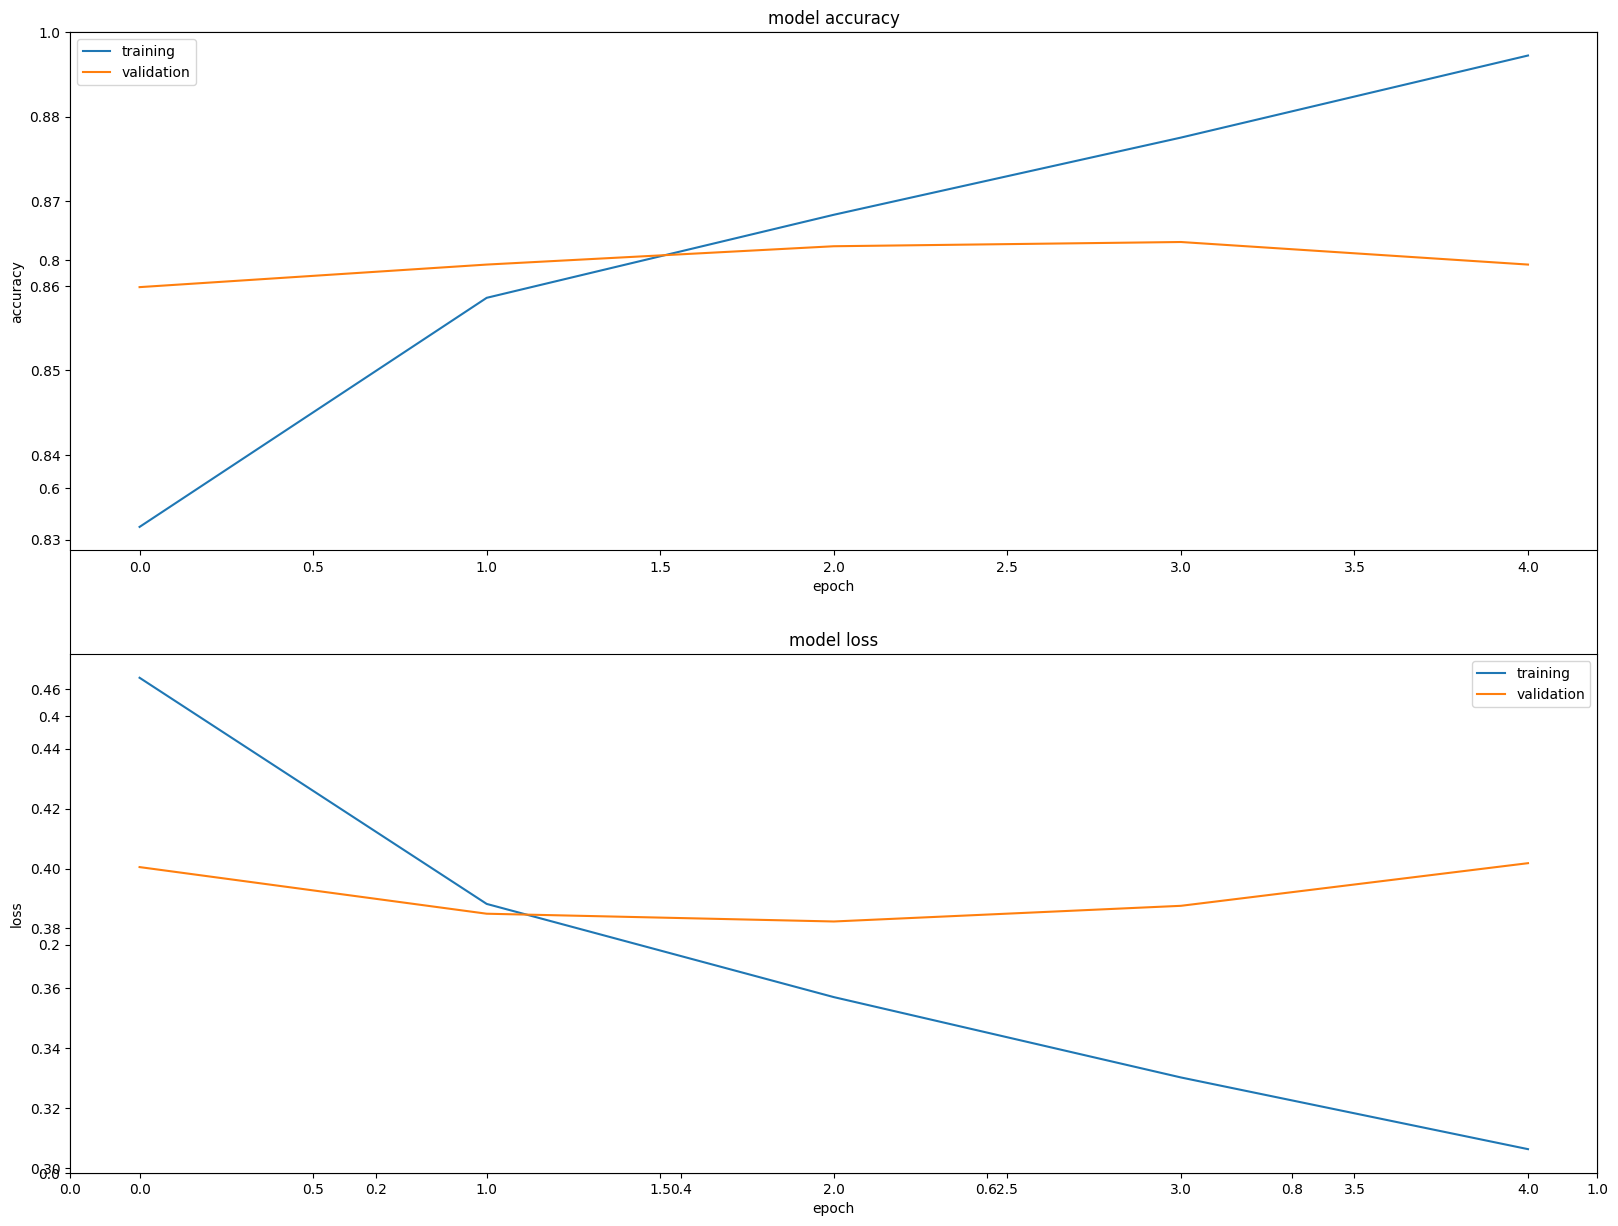

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1900
           1       0.91      0.92      0.92      1900
           2       0.85      0.82      0.83      1900
           3       0.81      0.83      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600

Accuracy Score: 0.8625
Root Mean Square Error: 0.6489870649915265


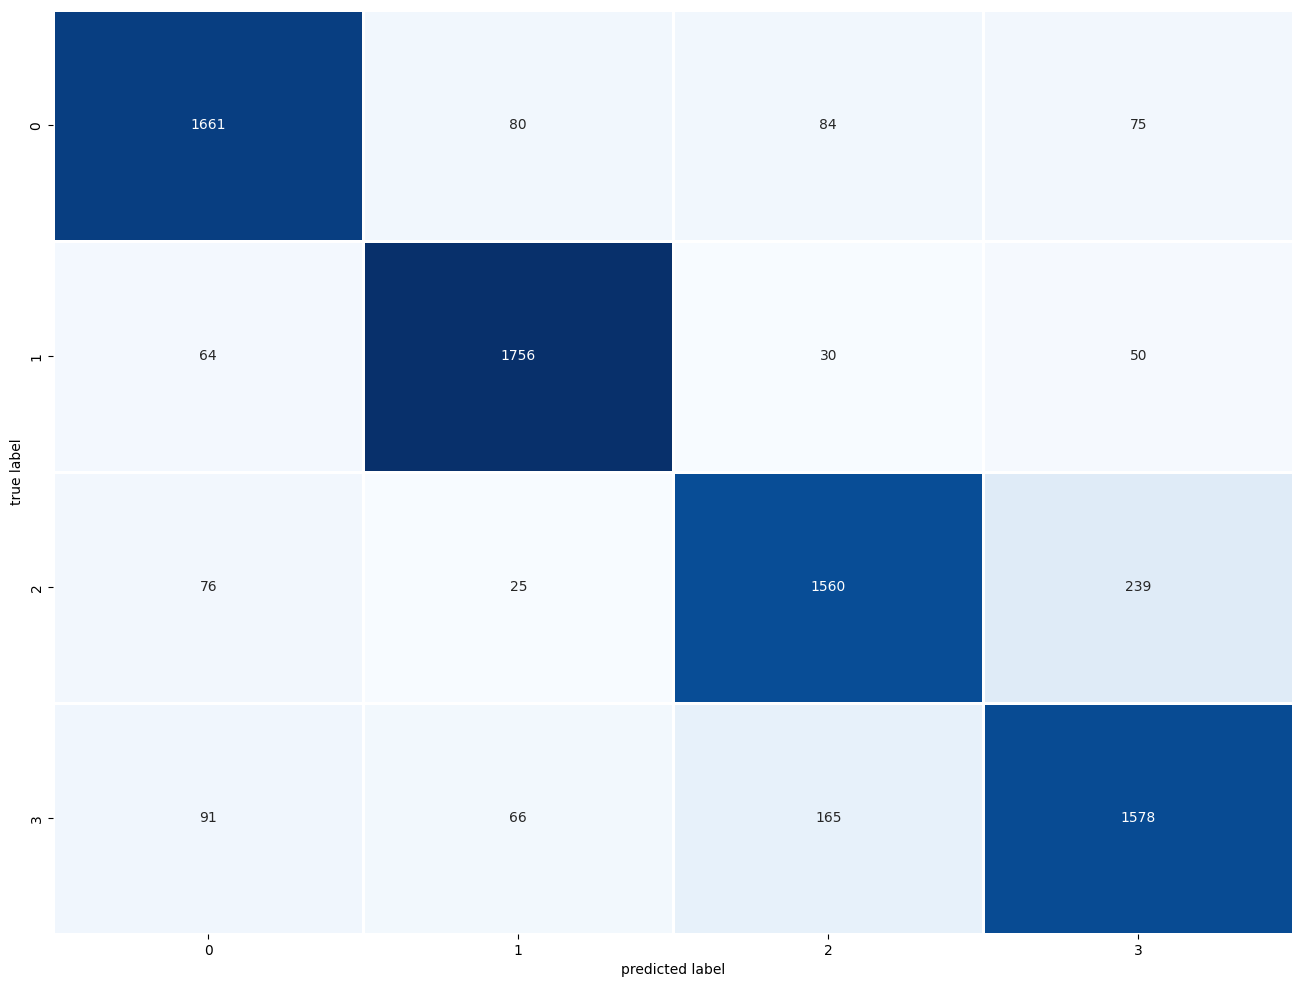

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 8
LSTM, 64 units

## Build Model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)
x = layers.LSTM(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=5
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.7847 - loss: 0.5686 - val_accuracy: 0.8577 - val_loss: 0.4052
Epoch 2/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8565 - loss: 0.3970 - val_accuracy: 0.8610 - val_loss: 0.3899
Epoch 3/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8669 - loss: 0.3629 - val_accuracy: 0.8623 - val_loss: 0.3875
Epoch 4/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8761 - loss: 0.3347 - val_accuracy: 0.8600 - val_loss: 0.3945
Epoch 5/5
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8851 - loss: 0.3081 - val_accuracy: 0.8590 - val_loss: 0.4105
Total time elapsed (s) 115.54426622390747


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     82,176 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,027,790 (3.92 MB)

 Trainable params: 342,596 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 685,194 (2.61 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8596 - loss: 0.4058
Test accuracy: 0.8600000143051147


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.829,0.470,0.858,0.405
1,0.858,0.391,0.861,0.390
2,0.868,0.358,0.862,0.388
3,0.878,0.330,0.860,0.395
4,0.888,0.303,0.859,0.410


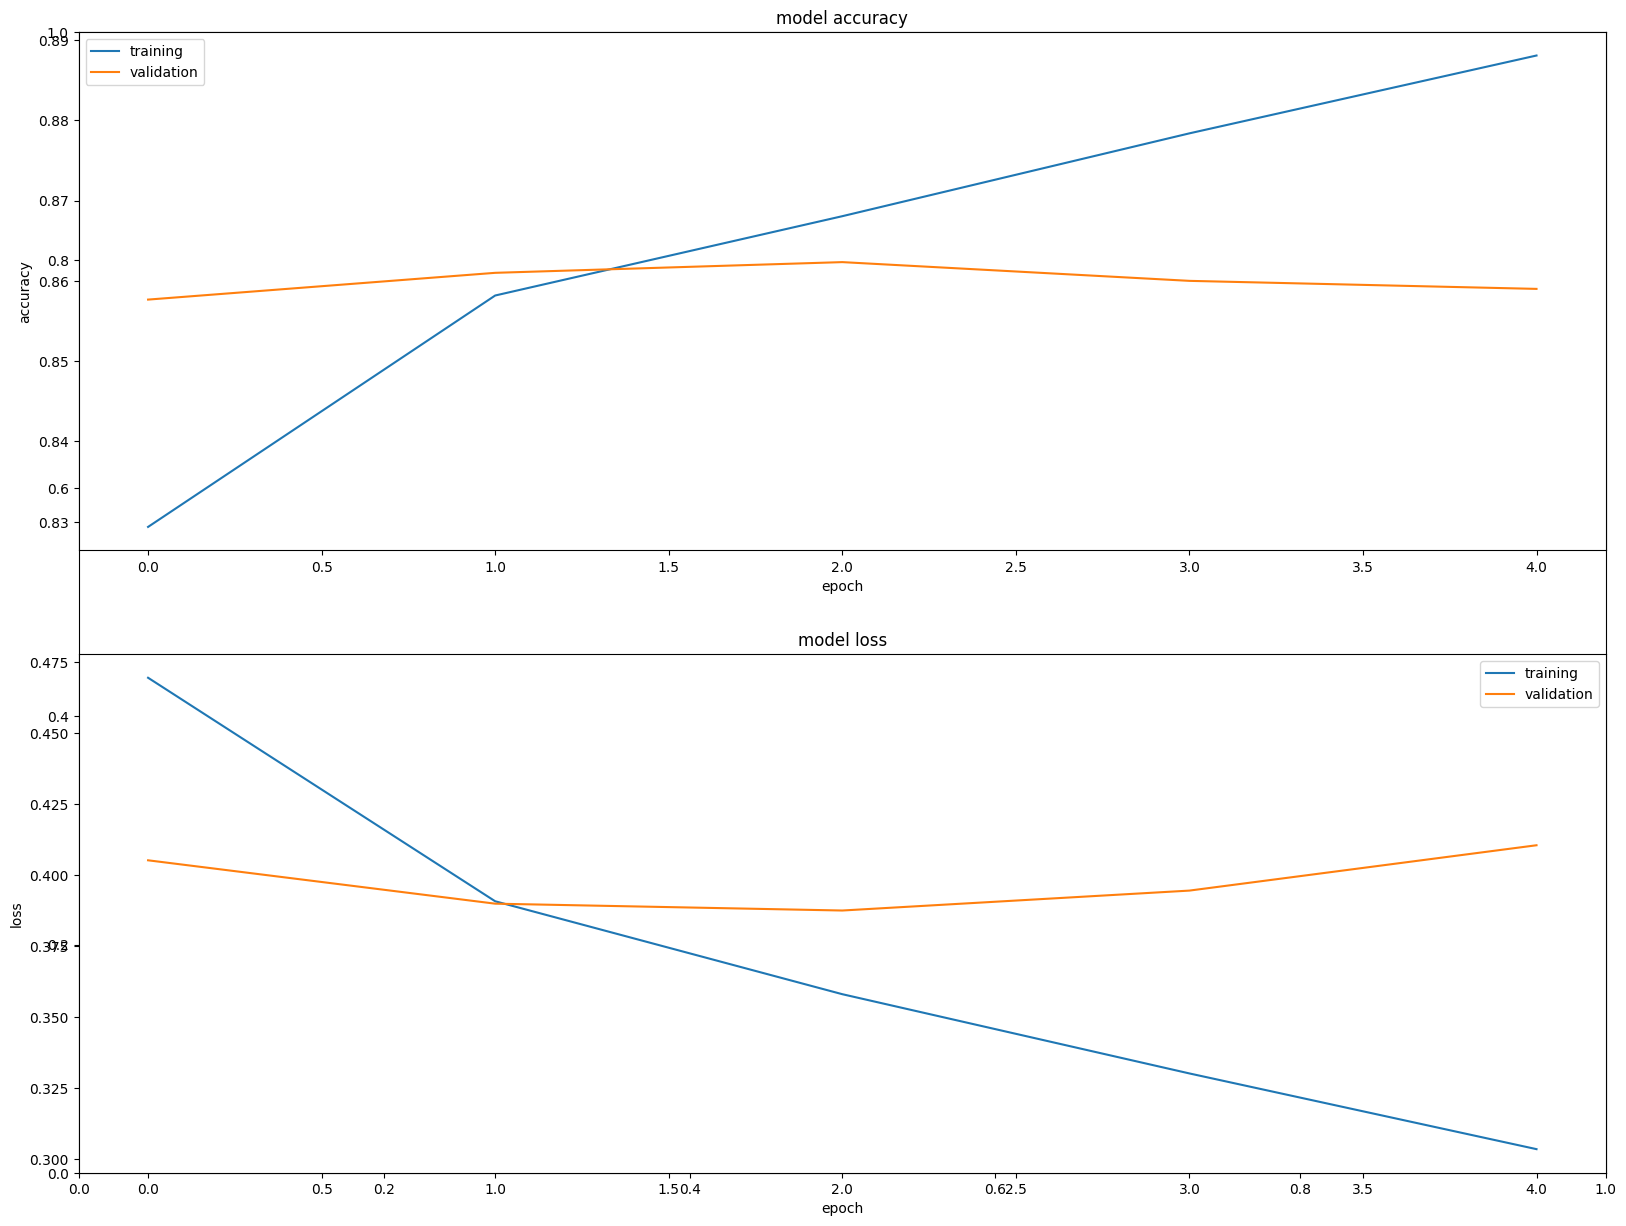

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1900
           1       0.91      0.92      0.92      1900
           2       0.84      0.82      0.83      1900
           3       0.81      0.83      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600

Accuracy Score: 0.86
Root Mean Square Error: 0.6639197795548876


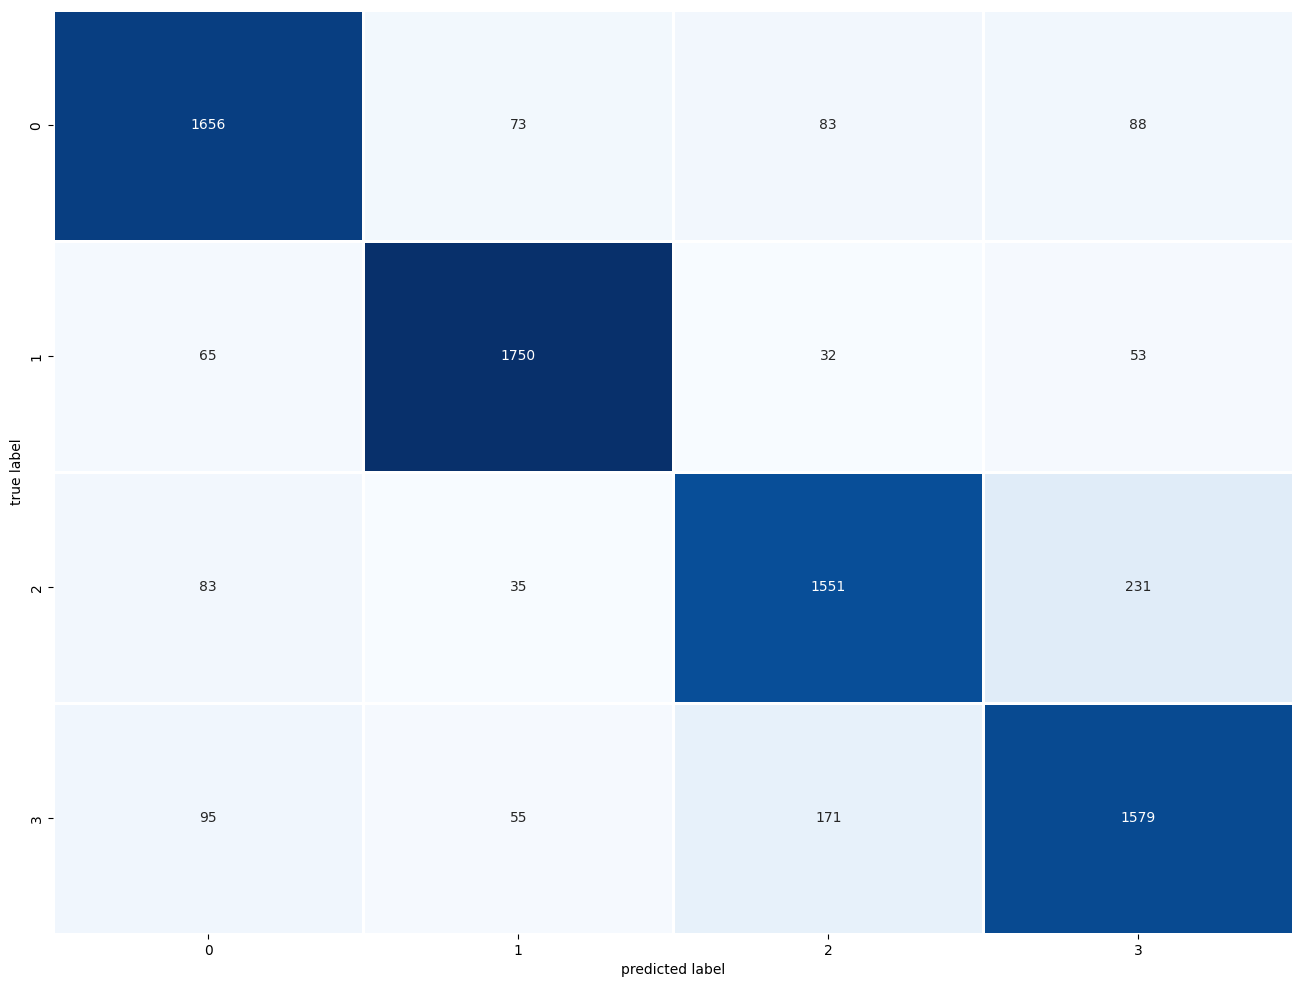

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 9
LSTM, 64 units, Early Stopping

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
BATCH_SIZE = 32

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)
x = layers.LSTM(RNN_UNITS)(embedded)
x =  layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("RNN.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)

stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.7879 - loss: 0.5602 - val_accuracy: 0.8562 - val_loss: 0.4019
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8561 - loss: 0.3960 - val_accuracy: 0.8590 - val_loss: 0.3894
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8667 - loss: 0.3628 - val_accuracy: 0.8630 - val_loss: 0.3868
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8749 - loss: 0.3335 - val_accuracy: 0.8632 - val_loss: 0.3923
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8854 - loss: 0.3075 - val_accuracy: 0.8608 - val_loss: 0.4083
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.8955 - loss: 0.2810 - val_accuracy: 0.8535 - val_loss: 0.4356
Epoch 7/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9056 - loss: 0.2558 - val_accuracy: 0.8510 - val_loss: 0.4667
Total time elapsed (s) 162.11597394943237


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     82,176 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,027,790 (3.92 MB)

 Trainable params: 342,596 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 685,194 (2.61 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8548 - loss: 0.4623
Test accuracy: 0.855526328086853


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
2,0.869,0.357,0.863,0.387
3,0.878,0.329,0.863,0.392
4,0.889,0.303,0.861,0.408
5,0.899,0.276,0.854,0.436
6,0.908,0.250,0.851,0.467


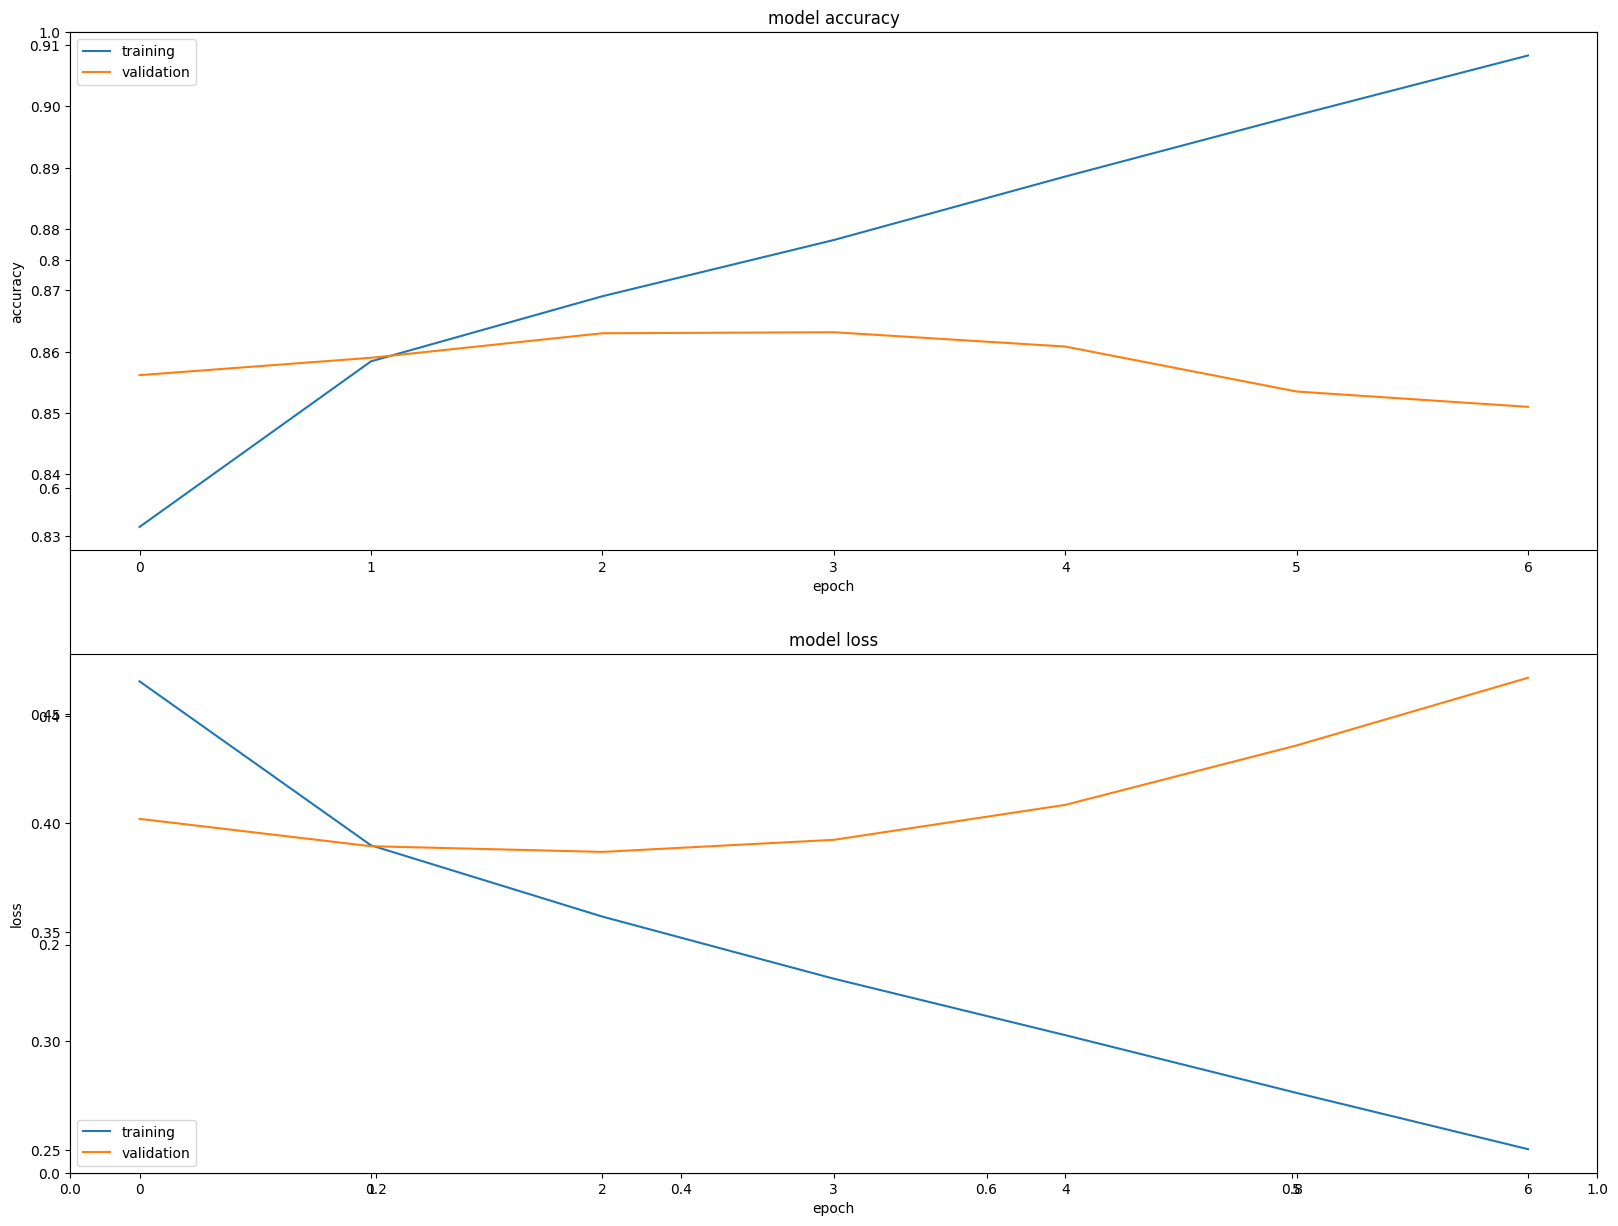

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1900
           1       0.92      0.90      0.91      1900
           2       0.85      0.80      0.83      1900
           3       0.80      0.83      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600

Accuracy Score: 0.8555263157894737
Root Mean Square Error: 0.6834509954326606


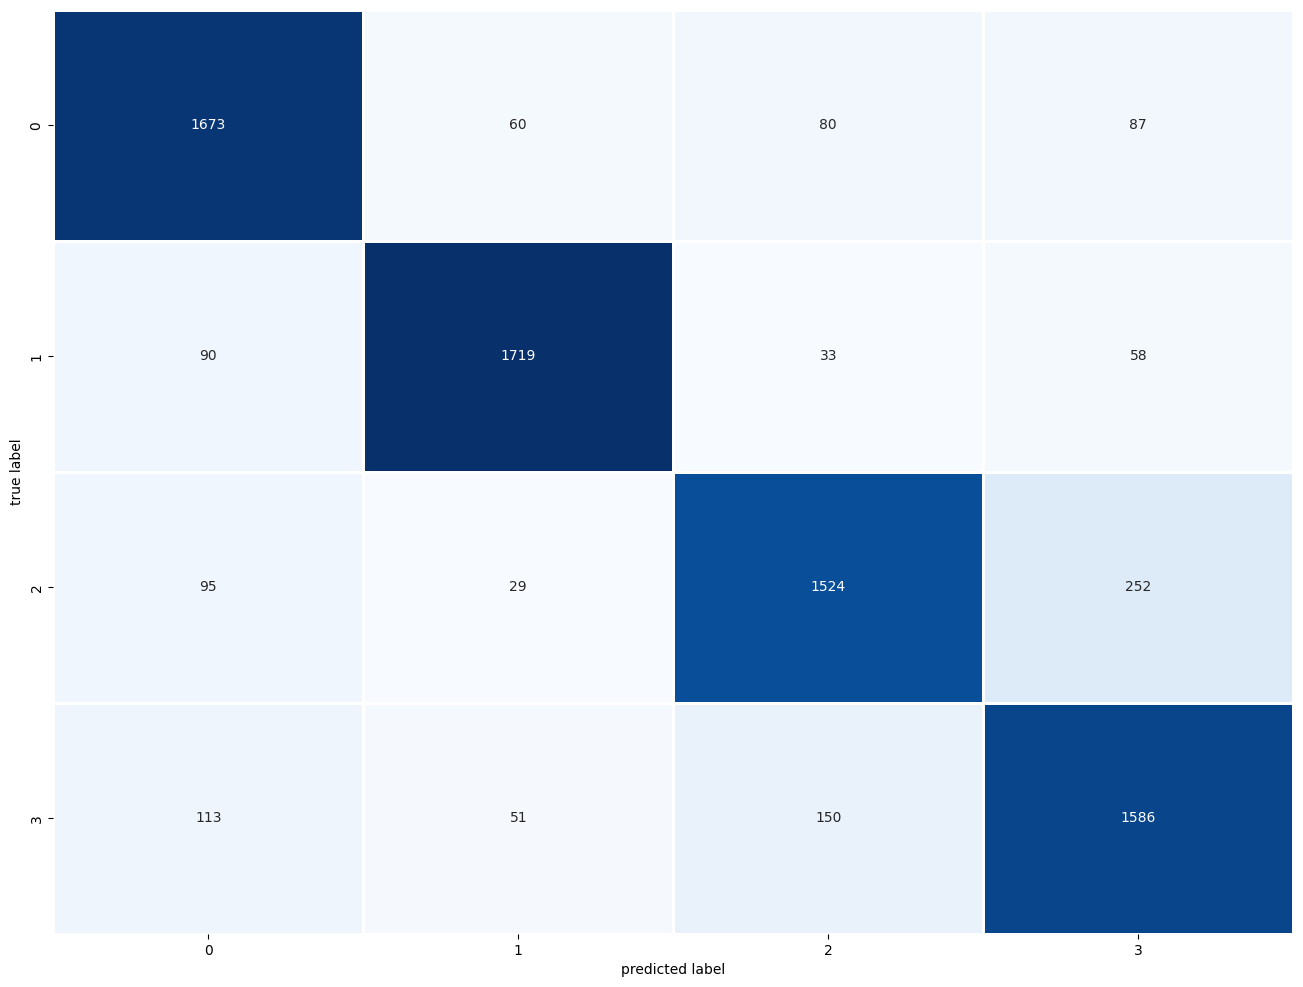

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 10
LSTM, 64 units, Early Stopping, L2 regularization

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
L2_VALUE = 0.001

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True
                             ,embeddings_regularizer=regularizers.l2(L2_VALUE))(inputs)
x = layers.LSTM(RNN_UNITS,
                     kernel_regularizer=regularizers.l2(L2_VALUE),
                    recurrent_regularizer=regularizers.l2(L2_VALUE),
                    bias_regularizer=regularizers.l2(L2_VALUE))(embedded)
x =  layers.Dense(64,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="relu")(x)
outputs = layers.Dense(4,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("RNN.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)



stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.7486 - loss: 0.8541 - val_accuracy: 0.8333 - val_loss: 0.5914
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8367 - loss: 0.5796 - val_accuracy: 0.8412 - val_loss: 0.5595
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8413 - loss: 0.5532 - val_accuracy: 0.8422 - val_loss: 0.5479
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8443 - loss: 0.5416 - val_accuracy: 0.8443 - val_loss: 0.5391
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8454 - loss: 0.5344 - val_accuracy: 0.8460 - val_loss: 0.5355
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8470 - loss: 0.5284 - val_accuracy: 0.8472 - val_loss: 0.5279
Epoch 7/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8474 - loss: 0.5218 - val_accuracy: 0.8495 - val_loss: 0.5195
Epoch 8/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8493 -

## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     82,176 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,027,790 (3.92 MB)

 Trainable params: 342,596 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 685,194 (2.61 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8432 - loss: 0.5236
Test accuracy: 0.8453947305679321


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
5,0.846,0.529,0.847,0.528
6,0.847,0.522,0.850,0.520
7,0.849,0.517,0.849,0.515
8,0.849,0.515,0.850,0.515
9,0.849,0.514,0.849,0.514


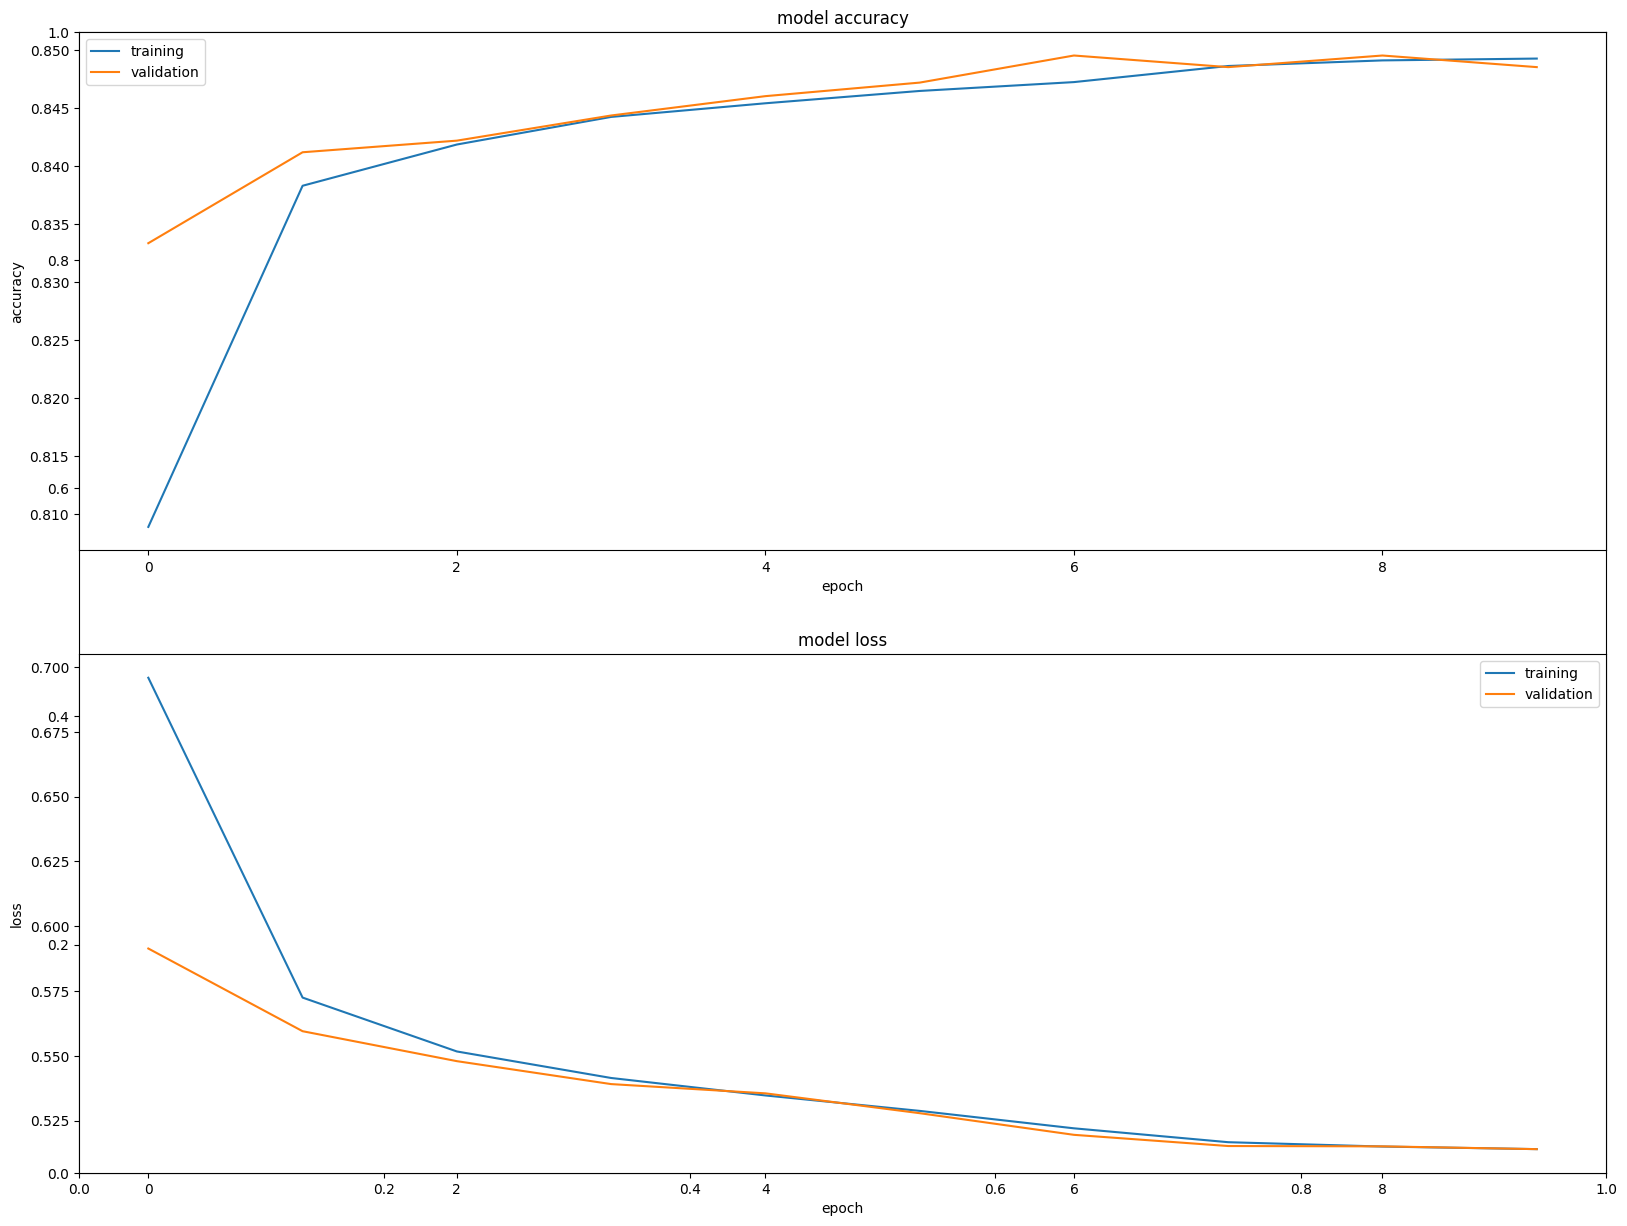

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1900
           1       0.93      0.90      0.91      1900
           2       0.84      0.79      0.81      1900
           3       0.80      0.82      0.81      1900

    accuracy                           0.85      7600
   macro avg       0.85      0.85      0.85      7600
weighted avg       0.85      0.85      0.85      7600

Accuracy Score: 0.8453947368421053
Root Mean Square Error: 0.7041231949625083


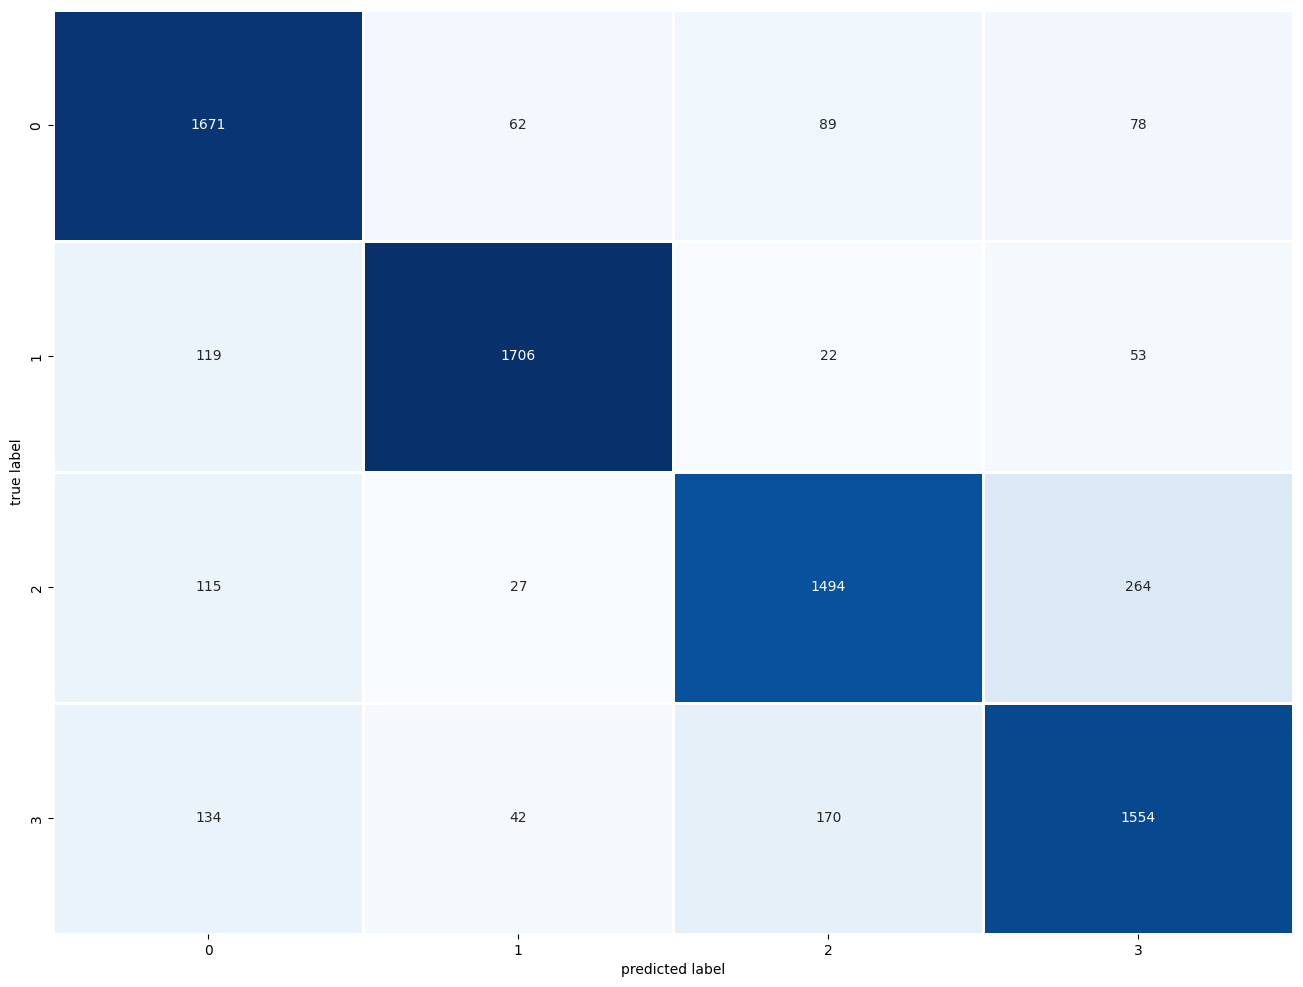

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 11
Bidirectional LSTM, 64 units, Early Stopping, L2 Regularization

## Build and compile  model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
L2_VALUE = 0.001

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True
                             ,embeddings_regularizer=regularizers.l2(L2_VALUE))(inputs)
x = layers.Bidirectional(layers.LSTM(RNN_UNITS,
                     kernel_regularizer=regularizers.l2(L2_VALUE),
                    recurrent_regularizer=regularizers.l2(L2_VALUE),
                    bias_regularizer=regularizers.l2(L2_VALUE)))(embedded)
x =  layers.Dense(64,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="relu")(x)
outputs = layers.Dense(4,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("lstm.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)



stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.7527 - loss: 0.8902 - val_accuracy: 0.8268 - val_loss: 0.6121
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8235 - loss: 0.5997 - val_accuracy: 0.8280 - val_loss: 0.5855
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8289 - loss: 0.5745 - val_accuracy: 0.8308 - val_loss: 0.5749
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8300 - loss: 0.5676 - val_accuracy: 0.8300 - val_loss: 0.5709
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8309 - loss: 0.5610 - val_accuracy: 0.8312 - val_loss: 0.5620
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8321 - loss: 0.5542 - val_accuracy: 0.8337 - val_loss: 0.5581
Epoch 7/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8321 - loss: 0.5510 - val_accuracy: 0.8350 - val_loss: 0.5540
Epoch 8/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 

## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │    164,352 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,286,606 (4.91 MB)

 Trainable params: 428,868 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 857,738 (3.27 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8317 - loss: 0.5480
Test accuracy: 0.832105278968811


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
16,0.834,0.543,0.838,0.542
17,0.833,0.543,0.838,0.541
18,0.834,0.542,0.837,0.541
19,0.834,0.542,0.838,0.540
20,0.834,0.542,0.838,0.540


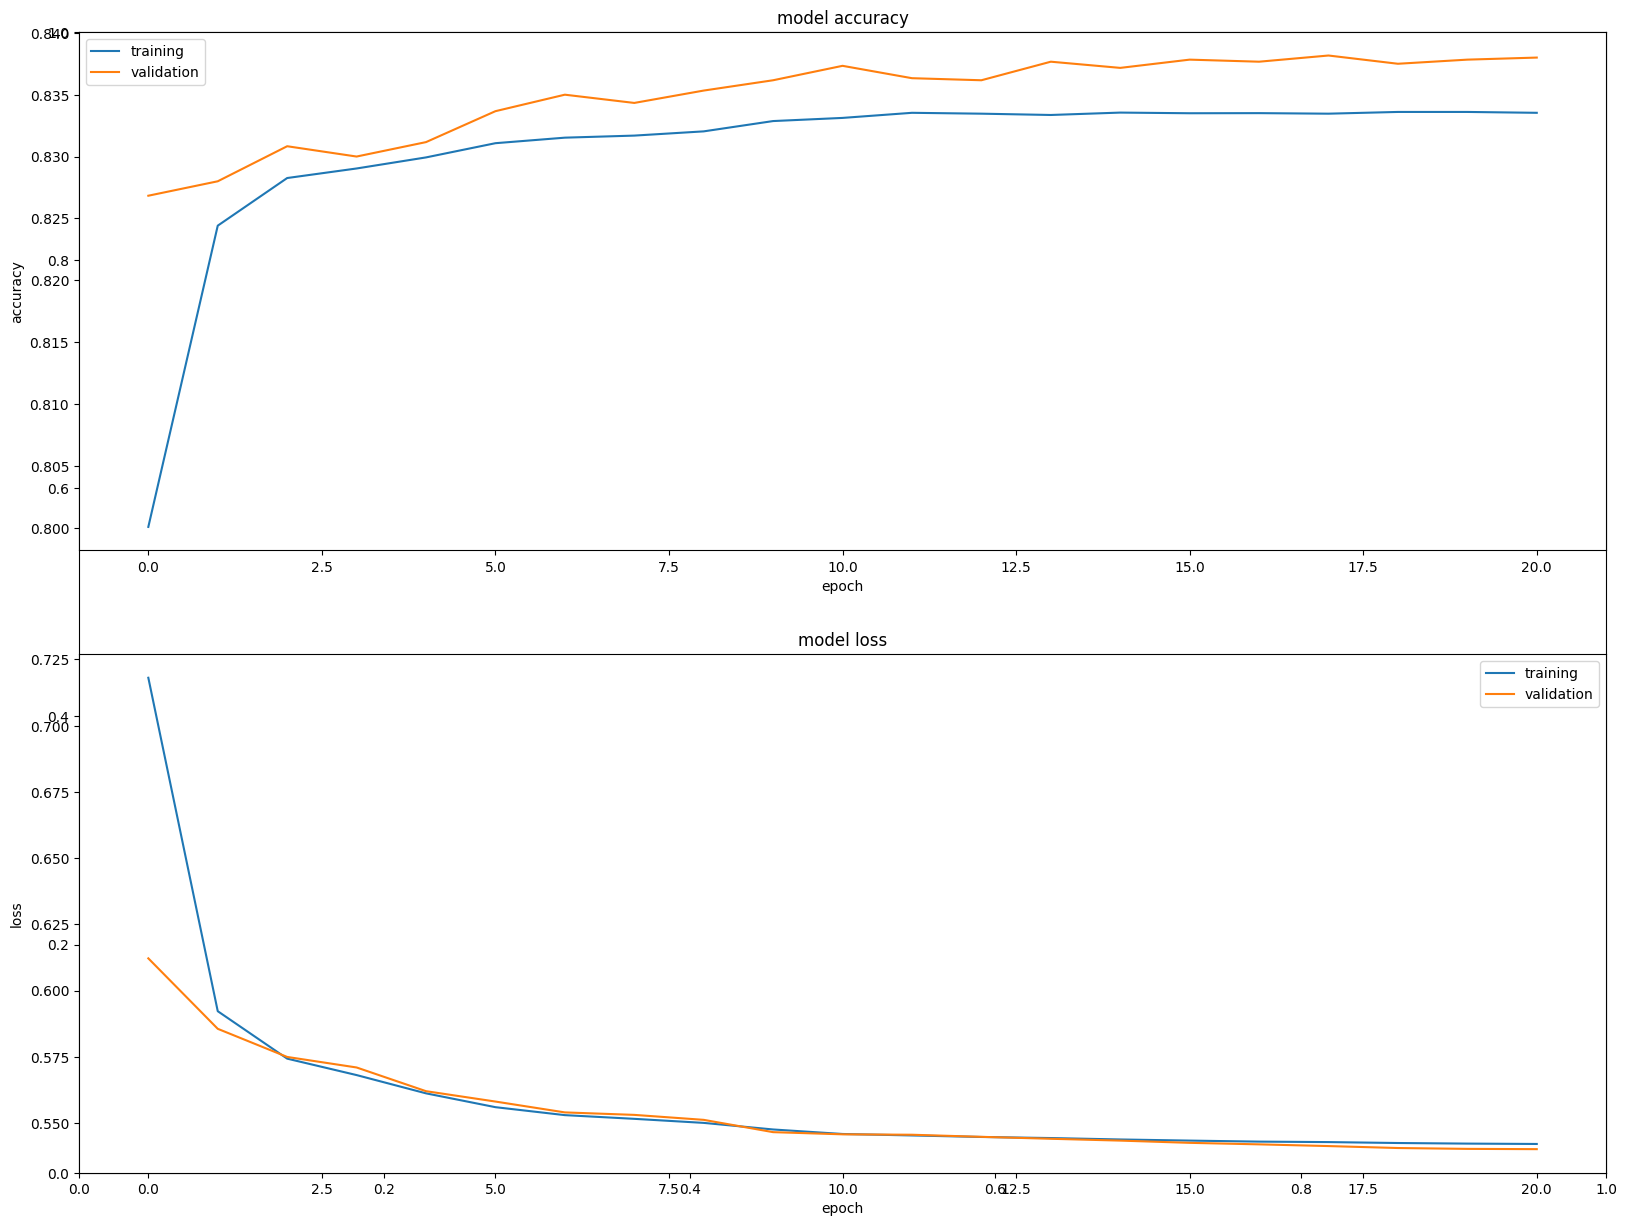

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1900
           1       0.91      0.89      0.90      1900
           2       0.80      0.79      0.79      1900
           3       0.76      0.82      0.79      1900

    accuracy                           0.83      7600
   macro avg       0.83      0.83      0.83      7600
weighted avg       0.83      0.83      0.83      7600

Accuracy Score: 0.8321052631578948
Root Mean Square Error: 0.7022520165416701


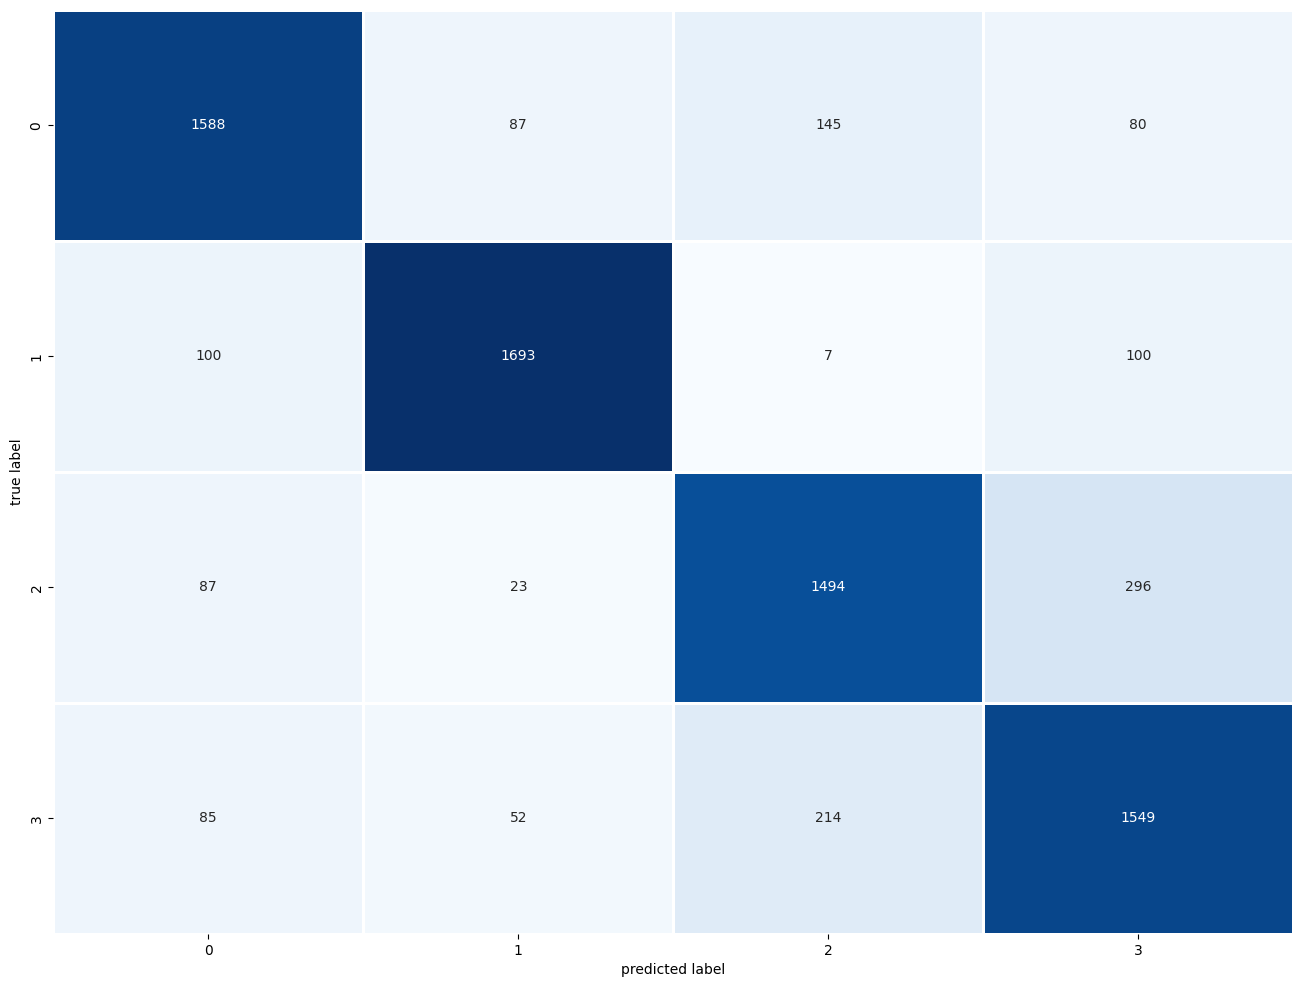

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 12
Bidirectional LSTM, 64 units, Early Stopping, L2 Regularization, Dropout

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
RNN_UNITS = 64
L2_VALUE = 0.001

start = time.time()

# Build Simple RNN model
inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True
                             ,embeddings_regularizer=regularizers.l2(L2_VALUE))(inputs)
x = layers.Bidirectional(layers.LSTM(RNN_UNITS,
                     kernel_regularizer=regularizers.l2(L2_VALUE),
                    recurrent_regularizer=regularizers.l2(L2_VALUE),
                    bias_regularizer=regularizers.l2(L2_VALUE)))(embedded)
x =  layers.Dense(64,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4,  kernel_regularizer=regularizers.l2(L2_VALUE), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("RNN.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

# Train
history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=200,
    callbacks=callbacks
)



stop = time.time()

print("Total time elapsed (s)", stop-start)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.7407 - loss: 0.9282 - val_accuracy: 0.8362 - val_loss: 0.5952
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8316 - loss: 0.6199 - val_accuracy: 0.8465 - val_loss: 0.5596
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8364 - loss: 0.5933 - val_accuracy: 0.8467 - val_loss: 0.5522
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.8391 - loss: 0.5780 - val_accuracy: 0.8500 - val_loss: 0.5439
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8410 - loss: 0.5704 - val_accuracy: 0.8498 - val_loss: 0.5321
Epoch 6/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8435 - loss: 0.5627 - val_accuracy: 0.8502 - val_loss: 0.5302
Epoch 7/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8439 - loss: 0.5582 - val_accuracy: 0.8470 - val_loss: 0.5317
Epoch 8/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 

## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │    256,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │    164,352 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,286,606 (4.91 MB)

 Trainable params: 428,868 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 857,738 (3.27 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8381 - loss: 0.5574
Test accuracy: 0.8384210467338562


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
6,0.844,0.559,0.847,0.532
7,0.843,0.557,0.853,0.524
8,0.844,0.553,0.849,0.530
9,0.844,0.553,0.849,0.531
10,0.844,0.553,0.847,0.539


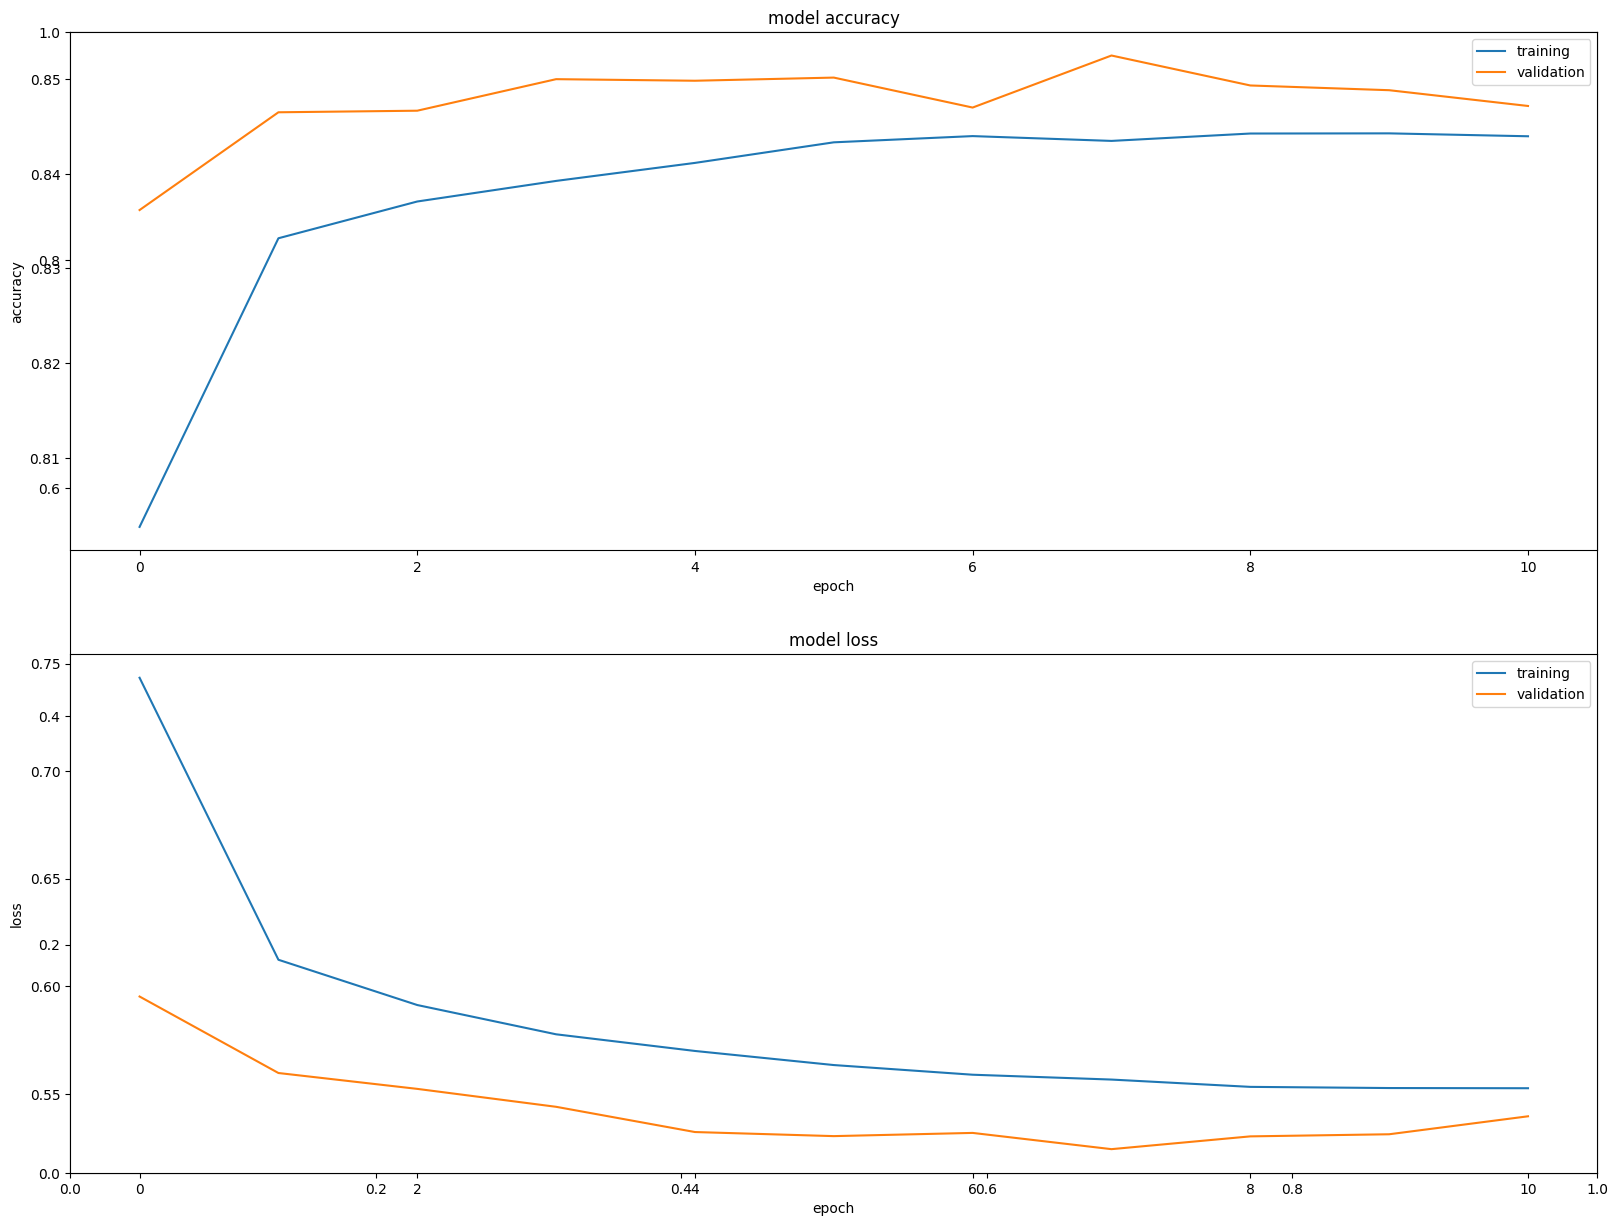

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1900
           1       0.94      0.86      0.90      1900
           2       0.85      0.78      0.81      1900
           3       0.74      0.87      0.80      1900

    accuracy                           0.84      7600
   macro avg       0.85      0.84      0.84      7600
weighted avg       0.85      0.84      0.84      7600

Accuracy Score: 0.838421052631579
Root Mean Square Error: 0.7302667140738448


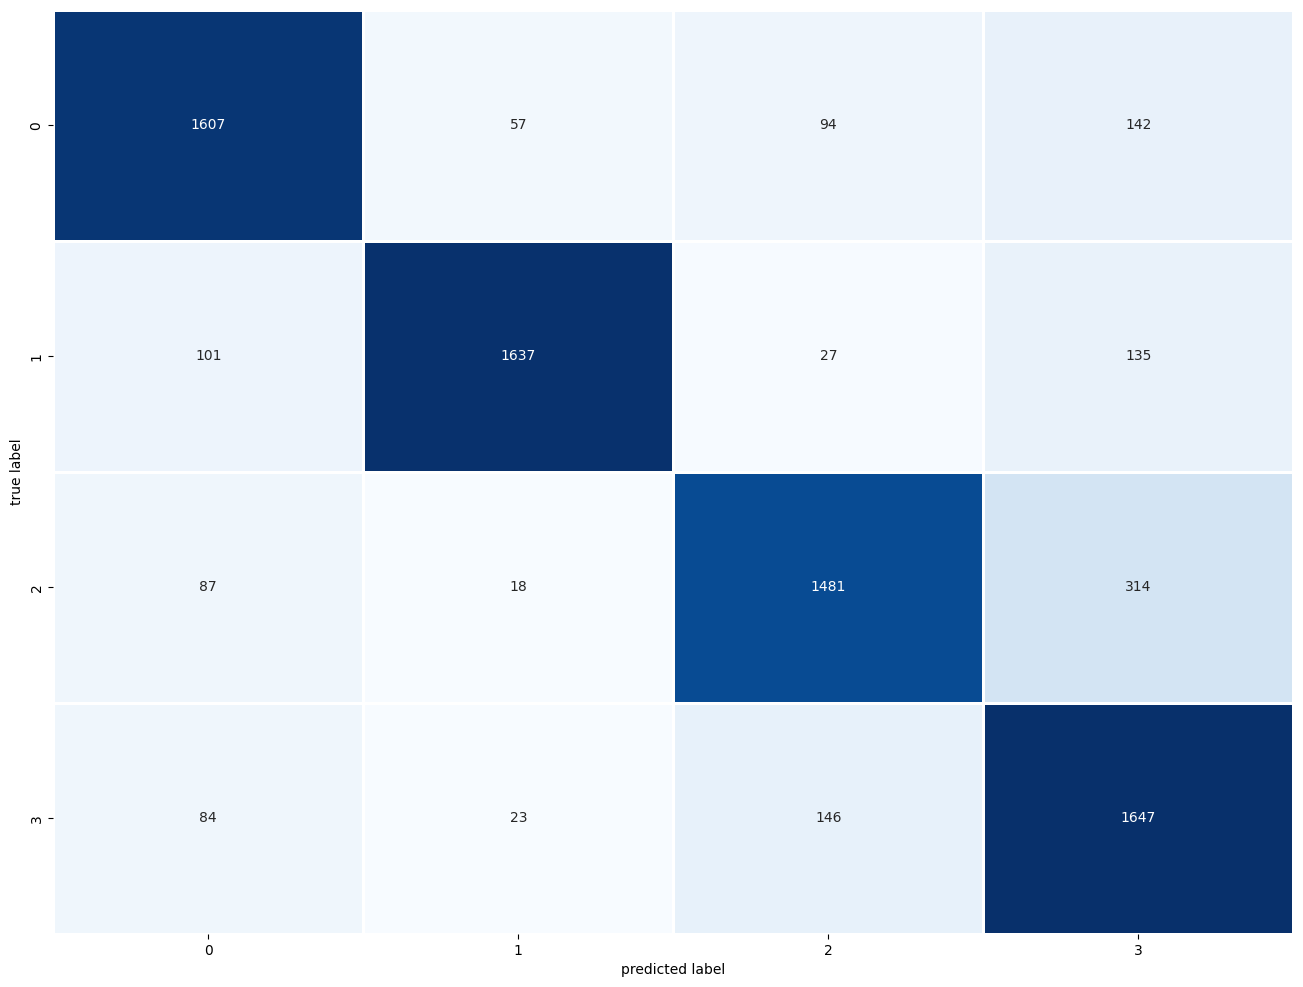

In [ ]:
plot_confusion_matrix(y_test,pred_classes)

# Experiment 13
1D CNN, with 32 filters, Dropout, Early Stopping

## Build and compile model

In [ ]:
k.clear_session()

# Parameters
EMBED_DIM = 256
L2_VALUE = 0.001

inputs = tf.keras.Input(shape=(None,), dtype="int64")
embedded = layers.Embedding(input_dim=max_tokens
                            ,output_dim=EMBED_DIM
                            ,mask_zero=True)(inputs)

x = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(embedded)
x = layers.Dropout(0.5)(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="adam",
              loss="SparseCategoricalCrossentropy",
              metrics=["accuracy"])
model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("1Dcnn.keras",save_best_only=True)
    ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]
history=model.fit(int_train_ds, validation_data=int_val_ds, epochs=200, callbacks=callbacks)
model = keras.models.load_model("1Dcnn.keras")
print(f"Test acc: {model.evaluate(int_test_ds)[1]:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 32)       │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,084 (1.11 MB)

 Trainable params: 290,084 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 32s 7ms/step - accuracy: 0.7783 - loss: 0.5944 - val_accuracy: 0.8560 - val_loss: 0.4621
Epoch 2/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8447 - loss: 0.4336 - val_accuracy: 0.8572 - val_loss: 0.4574
Epoch 3/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.8502 - loss: 0.4244 - val_accuracy: 0.8553 - val_loss: 0.4457
Epoch 4/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step - accuracy: 0.8491 - loss: 0.4276 - val_accuracy: 0.8553 - val_loss: 0.4385
Epoch 5/200
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - accuracy: 0.8476 - loss: 0.4317 - val_accuracy: 0.8563 - val_loss: 0.4424
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8554 - loss: 0.4399
Test acc: 0.854


## Evaluate

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 32)       │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 580,170 (2.21 MB)

 Trainable params: 290,084 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 290,086 (1.11 MB)

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(int_test_ds)

print("Test accuracy:", test_acc)

238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8554 - loss: 0.4399
Test accuracy: 0.8544737100601196


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot metrics

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.824,0.492,0.856,0.462
1,0.846,0.433,0.857,0.457
2,0.849,0.428,0.855,0.446
3,0.848,0.432,0.855,0.438
4,0.848,0.434,0.856,0.442


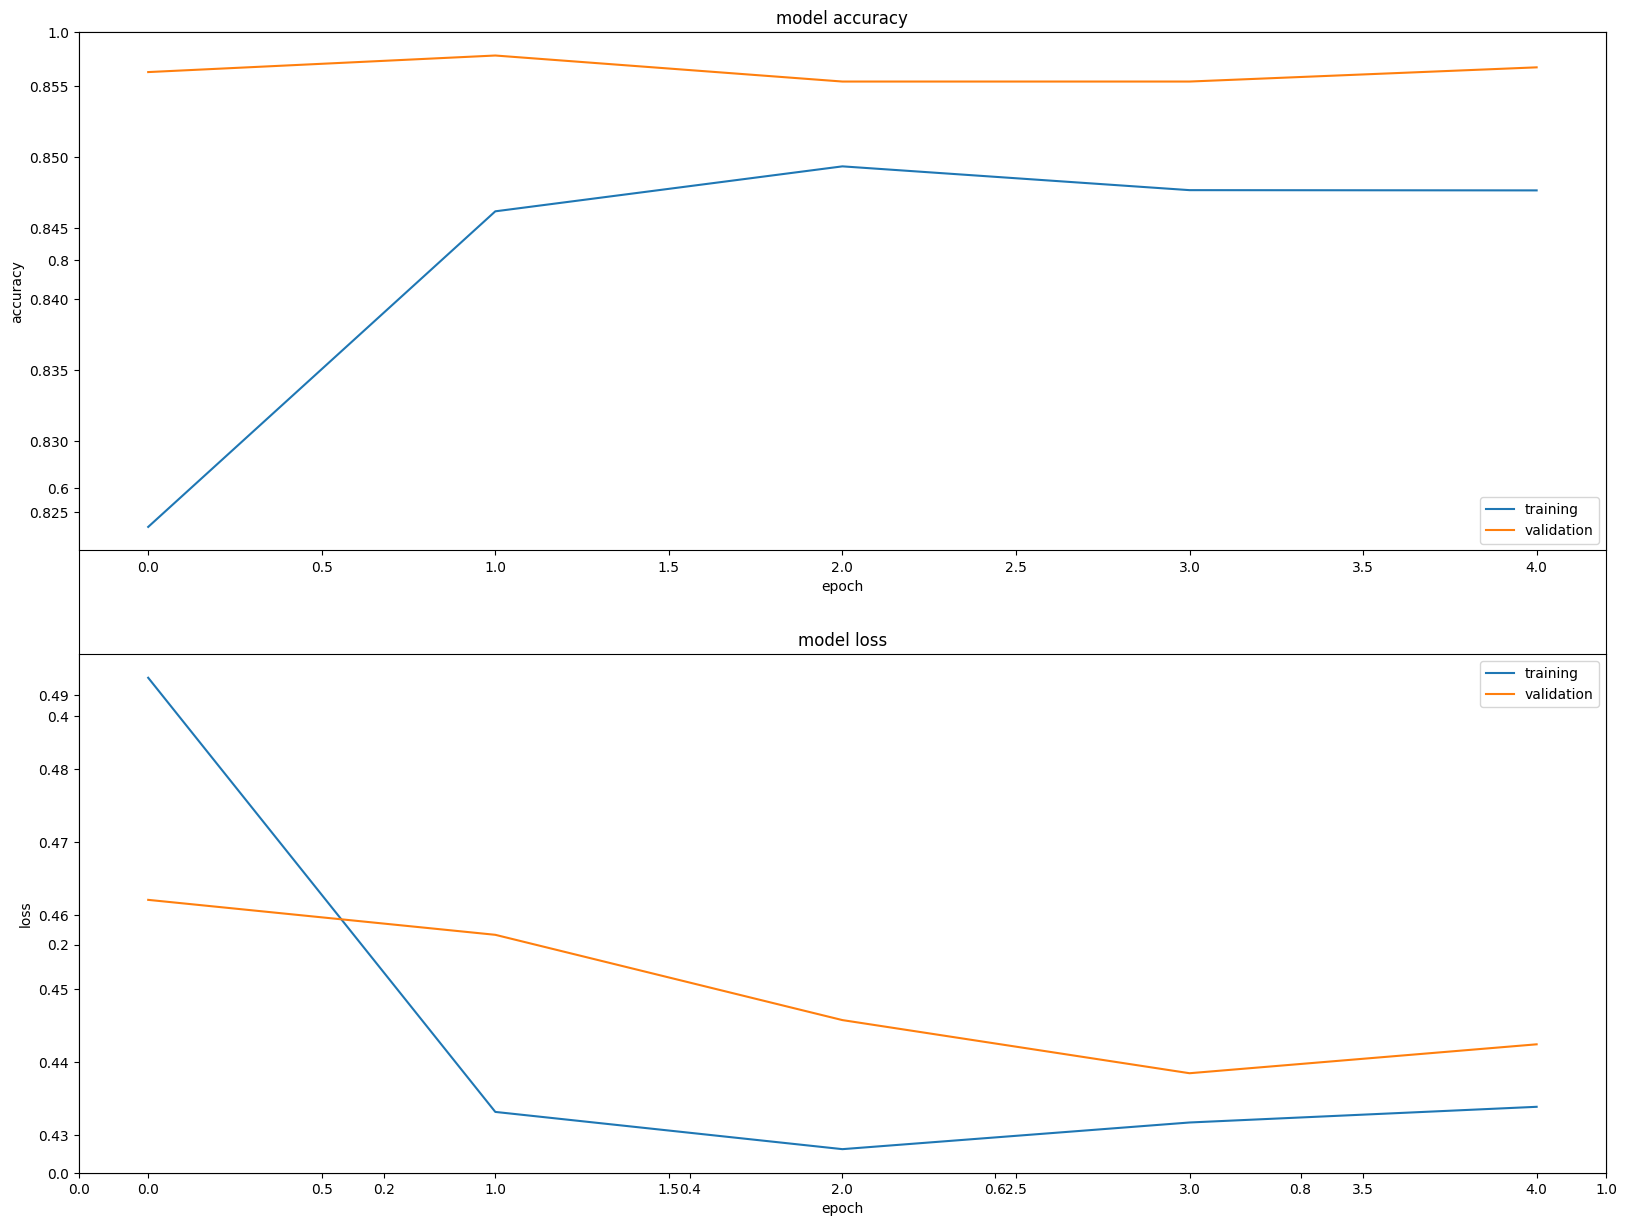

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(model.predict(int_test_ds), axis=-1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print_validation_report(y_test, pred_classes)

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1900
           1       0.88      0.95      0.91      1900
           2       0.87      0.78      0.82      1900
           3       0.82      0.82      0.82      1900

    accuracy                           0.85      7600
   macro avg       0.85      0.85      0.85      7600
weighted avg       0.85      0.85      0.85      7600

Accuracy Score: 0.8544736842105263
Root Mean Square Error: 0.6754141029963142


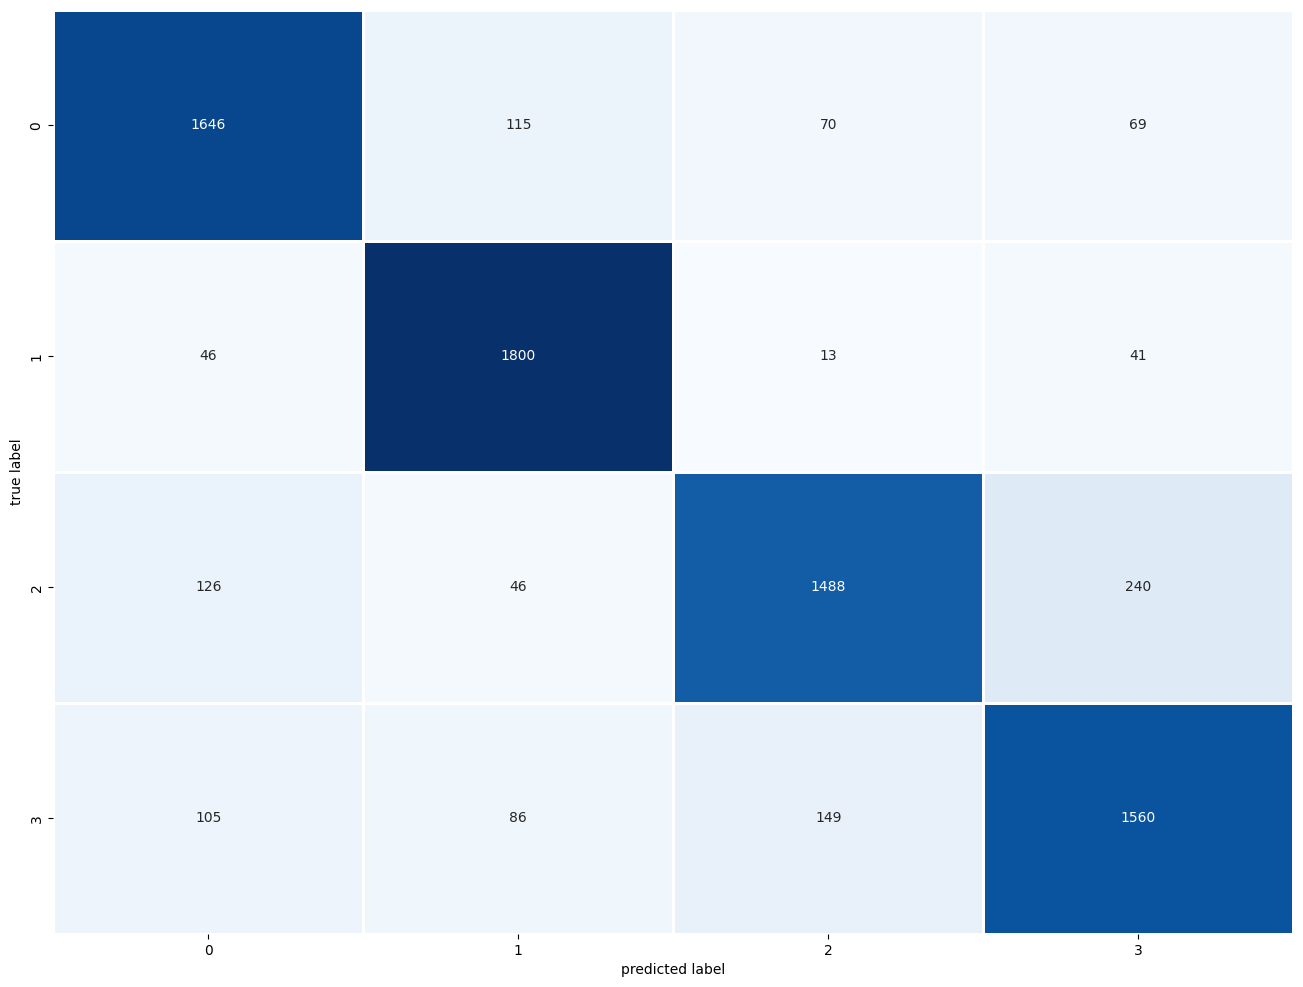

In [ ]:
plot_confusion_matrix(y_test,pred_classes)